# DSpark from scratch: a hands-on tour of the training pipeline

This notebook rebuilds, in plain PyTorch and on a handful of Open-PerfectBlend rows, everything that
`scripts/dspark_qwen3_0_6b_perfectblend_regen_online_think_mooncake_100k.sh` does. The code in each cell is
deliberately written to look like the code in the `speculators` fork (same function names, same tensor shapes, nearly the same lines),
so you can read a cell here and then open the real file and recognise it. Every important cell starts with a
**Library reference** line pointing at the file it mirrors (paths relative to `speculators/src/speculators/`).

**The pipeline in the script has four steps. The notebook follows them in order:**

| Script step | What it does | Notebook section |
|---|---|---|
| 1. `regenerate-responses` | Qwen3-0.6B rewrites every assistant turn itself (thinking on), giving on-policy rows of `input_ids` + `loss_mask` | §1 |
| 2. `prepare-data` | Packages the rows; builds the 32,000-token draft vocabulary from token frequencies | §2 |
| 3. hidden-state server | The verifier (Qwen3-0.6B) runs on each row and exposes layers 2, 14, 25 and 28 | §3 |
| 4. online training | Draft model learns to predict a *block of 8 tokens* from the verifier's hidden states | §4 to §8 |

Then §9 checks the numbers against the real thing: the vocabulary mapping and a real speculative-decoding loop run against the
checkpoint your 100k run produced (`runs/main/checkpoints/checkpoint_best`).

**What is scaled down** (so the whole notebook runs in a few minutes on one GPU):

| | script | notebook |
|---|---|---|
| conversations | 100,000 | 24 |
| `MAX_GEN_TOKENS` | 6,144 | 1,024 |
| `SEQ_LENGTH` (packed sequence) | 8,192 | 4,096 |
| `MAX_ANCHORS` per step | 3,072 | 256 |
| training | 1 epoch over ~119k rows (17,944 steps), 2 GPUs | 600 steps over ~20 rows, 1 GPU |

Everything else (model size, block size 8, layers 2/14/25, Markov rank 256, loss weights, LR, noise, optimizer) matches the run.
With ~20 training rows the small drafter will **memorise** them: that is expected, and the point of the exercise is to see every moving part, not
to get a good model. The 100k-row checkpoint is what a good model looks like, and §9 puts both side by side.

*Written for: you, reading and running this to learn how DSpark works. Run top to bottom; the first cell must run before PyTorch is imported.*

In [1]:
import os
PROJECT = "/mnt/nas/an34232/marin_speculator"
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "2")   # GPU 2 only (0 and 1 are used by other jobs). Must be set before torch is imported.
os.environ.update(                                   # same cache layout as env.sh: nothing heavy lands in $HOME or /tmp
    HF_HOME=f"{PROJECT}/cache/hf", HF_DATASETS_CACHE=f"{PROJECT}/cache/hf/datasets",
    TORCH_HOME=f"{PROJECT}/cache/torch", TRITON_CACHE_DIR=f"{PROJECT}/cache/triton",
    TORCHINDUCTOR_CACHE_DIR=f"{PROJECT}/cache/torch/inductor", XDG_CACHE_HOME=f"{PROJECT}/cache/xdg",
    TMPDIR=f"{PROJECT}/tmp", TOKENIZERS_PARALLELISM="false")

import copy, json, math, random, re, time, warnings
from collections import Counter
from pathlib import Path
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer
from transformers.models.qwen3.modeling_qwen3 import Qwen3MLP, Qwen3RMSNorm, Qwen3RotaryEmbedding
warnings.filterwarnings("ignore")

assert torch.cuda.is_available(), "this notebook expects a GPU (restart the kernel so CUDA_VISIBLE_DEVICES takes effect)"
device = "cuda"
print("torch", torch.__version__, "|", torch.cuda.get_device_name(0), "| visible GPUs:", torch.cuda.device_count())

# plotting style: thin lines, light grid, no top/right spines
BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e6e5e1", "grid.linewidth": 0.8, "axes.axisbelow": True, "lines.linewidth": 1.6})

torch 2.13.0+cu130 | NVIDIA H100 NVL | visible GPUs: 1


## 0. Configuration

These are the same knobs as the top of the shell script (names kept), with the scaled-down values marked.

In [2]:
# ---- same as the script ----
MODEL            = "Qwen/Qwen3-0.6B"
ENABLE_THINKING  = True
SAMPLING         = dict(temperature=0.6, top_p=0.95, top_k=20)   # Qwen3's recommended thinking-mode sampling (script: SAMPLING_PARAMS)
BLOCK_SIZE       = 8              # tokens drafted per step
NUM_LAYERS       = 3              # draft decoder layers
TARGET_LAYER_IDS = [2, 14, 25]    # verifier layers fed to the draft; the server also appends the last layer (28)
DRAFT_VOCAB_SIZE = 32000          # reduced output vocabulary
MARKOV_RANK      = 256
MARKOV_HEAD_TYPE = "vanilla"      # vanilla | gated | rnn
LOSS_WEIGHTS     = {"ce": 0.1, "tv": 0.9}
CONF_ALPHA       = 1.0            # weight of the confidence-head BCE term
GAMMA            = 4.0            # per-position loss decay: w_k = exp(-k / GAMMA)
LR               = 3e-4
GRAD_CLIP        = 1.0
NOISE_STD        = 0.05           # uniform noise added to the hidden states during training
TRAIN_RATIO      = 0.9            # train/val split by row index, as in the library

# ---- scaled down ----
N_CONVS          = 24             # script: 100,000
MAX_USER_TURNS   = 2              # keep conversations with at most this many user turns (the script regenerates all of them)
MAX_PROMPT_TOKENS = 300           # keep short prompts so regeneration is fast
MAX_GEN_TOKENS   = 1024           # script: 6,144
SEQ_LENGTH       = 4096           # script: 8,192
MAX_ANCHORS      = 256            # script: 3,072
TRAIN_STEPS      = 600
SEED             = 0

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
tok = AutoTokenizer.from_pretrained(MODEL)
verifier_cfg = AutoConfig.from_pretrained(MODEL)
IM_END, EOT = tok.convert_tokens_to_ids("<|im_end|>"), tok.convert_tokens_to_ids("<|endoftext|>")
MASK_ID = len(tok)   # train/utils.py::resolve_mask_token_id: Qwen3 has no mask token, so "<|MASK|>" is appended at id len(tokenizer)
print("verifier layers:", verifier_cfg.num_hidden_layers, "| hidden:", verifier_cfg.hidden_size, "| vocab:", verifier_cfg.vocab_size,
      "| mask token id:", MASK_ID, "(an unused row of the embedding table)")

verifier layers: 28 | hidden: 1024 | vocab: 151936 | mask token id: 151669 (an unused row of the embedding table)


## 1. Step 1: on-policy data (`speculators regenerate-responses`)

**Why regenerate?** A drafter is useful only if it predicts what *the target itself* would write. Open-PerfectBlend's original answers were written by
other models. So the script keeps only the *prompts* and has Qwen3-0.6B write fresh answers (with thinking on, at Qwen3's recommended sampling settings).
For multi-turn conversations each assistant turn is regenerated in order, on top of the model's own earlier answers.

**What a training row is.** Each generated turn becomes one row: `input_ids = prompt tokens + generated tokens` and
`loss_mask = 0` over the prompt, `1` over the generated tokens. Only generated tokens will ever be drafted or scored.

*Library reference: `cli/regenerate_responses.py` (`extract_conversation`, `regenerate_conversation`, `build_boundary_sample`).*
The library talks to a vLLM server; here we call `model.generate` directly, which gives the same token ids.

In [3]:
from datasets import load_dataset
ds = load_dataset("mlabonne/open-perfectblend", split="train")
print(f"{len(ds):,} conversations | columns: {ds.column_names}")

def extract_conversation(conv):
    """Mirrors cli/regenerate_responses.py::extract_conversation: keep system/user turns, DROP the original assistant turns."""
    turns = []
    for m in conv:
        role, content = (m.get("from") or m.get("role")), (m.get("value") or m.get("content"))
        if role in ("human", "user") and content: turns.append({"role": "user", "content": content})
        elif role == "system" and content:        turns.append({"role": "system", "content": content})
    return turns

rng = random.Random(SEED)
cand = rng.sample(range(len(ds)), 1500)
picked, spare = [], []
for i in cand:
    turns = extract_conversation(ds[i]["conversations"])
    n_user = sum(t["role"] == "user" for t in turns)
    n_tok = len(tok(" ".join(t["content"] for t in turns)).input_ids)
    if 1 <= n_user <= MAX_USER_TURNS and n_tok <= MAX_PROMPT_TOKENS:
        (picked if len(picked) < N_CONVS else spare).append(dict(idx=i, source=ds[i]["source"], turns=turns))
    if len(picked) >= N_CONVS and len(spare) >= 12: break
print(f"picked {len(picked)} conversations (+{len(spare)} spare prompts held out for the inference demo in section 9)")
print(Counter(p["source"] for p in picked).most_common())
print("\nexample prompt:\n", picked[0]["turns"][-1]["content"][:300])

1,420,909 conversations | columns: ['conversations', 'source']
picked 24 conversations (+12 spare prompts held out for the inference demo in section 9)
[('meta-math/MetaMathQA', 8), ('HuggingFaceH4/orca-math-word-problems-200k', 5), ('theblackcat102/evol-codealpaca-v1', 5), ('openbmb/UltraInteract_sft', 4), ('mlabonne/lmsys-arena-human-preference-55k-sharegpt', 1), ('HuggingFaceH4/ultrafeedback_binarized', 1)]

example prompt:
 Determine the remainder when the product $1734 \times 5389 \times 80,607$ is divided by 10.


In [4]:
# The verifier doubles as the generator here. bf16 on the GPU, like the vLLM server.
verifier = AutoModelForCausalLM.from_pretrained(MODEL, dtype=torch.bfloat16, attn_implementation="sdpa").to(device).eval()
for p in verifier.parameters(): p.requires_grad_(False)
print(f"verifier: {sum(p.numel() for p in verifier.parameters())/1e6:.0f}M params, tied embeddings: {verifier.config.tie_word_embeddings}")

@torch.no_grad()
def generate_turn(prefixes):
    """One batched call = one vLLM chat-completions request per conversation. Returns (prompt_ids, completion_ids, finish_reason)."""
    texts = [tok.apply_chat_template(p, tokenize=False, add_generation_prompt=True, enable_thinking=ENABLE_THINKING) for p in prefixes]
    tok.padding_side = "left"
    enc = tok(texts, return_tensors="pt", padding=True, add_special_tokens=False).to(device)
    out = verifier.generate(**enc, max_new_tokens=MAX_GEN_TOKENS, do_sample=True, pad_token_id=EOT, **SAMPLING)
    results = []
    for i in range(len(texts)):
        prompt_ids = enc.input_ids[i][enc.attention_mask[i].bool()].tolist()
        comp = out[i, enc.input_ids.shape[1]:].tolist()
        stops = [j for j, t in enumerate(comp) if t in (IM_END, EOT)]
        if stops: comp, finish = comp[: stops[0] + 1], "stop"       # keep the stop token, like vLLM's token_ids
        else:     finish = "length"
        results.append((prompt_ids, comp, finish))
    return results

def build_boundary_sample(prompt_ids, completion_ids):
    """Mirrors build_boundary_sample: prompt (loss_mask 0) + generated tokens (loss_mask 1)."""
    return prompt_ids + completion_ids, [0] * len(prompt_ids) + [1] * len(completion_ids)

def regenerate(convs):
    """Turn-by-turn regeneration, each answer is appended to the history before the next user turn is rendered."""
    rows, state = [], [dict(c=c, ptr=0, prefix=[], n=0) for c in convs]
    def advance(s):   # append system/user turns until the next user turn is in the prefix; True if a generation is needed
        turns = s["c"]["turns"]
        while s["ptr"] < len(turns):
            t = turns[s["ptr"]]; s["ptr"] += 1; s["prefix"].append(dict(t))
            if t["role"] == "user": return True
        return False
    active = [s for s in state if advance(s)]
    while active:
        for s, (p_ids, c_ids, finish) in zip(active, generate_turn([s["prefix"] for s in active])):
            ids, mask = build_boundary_sample(p_ids, c_ids)
            rows.append(dict(id=f"conv{s['c']['idx']}_gen{s['n']}", conv=s["c"]["idx"], source=s["c"]["source"],
                             input_ids=ids, loss_mask=mask, finish_reason=finish))
            s["n"] += 1
            s["prefix"].append(dict(role="assistant", content=tok.decode(c_ids, skip_special_tokens=True)))  # history for the next turn
        active = [s for s in active if advance(s)]
    return rows

CACHE = Path(PROJECT) / "tmp" / f"dspark_nb_regen_{N_CONVS}_{MAX_GEN_TOKENS}_{int(ENABLE_THINKING)}_{SEED}.json"
if CACHE.exists():
    rows = json.loads(CACHE.read_text()); print("loaded cached regeneration from", CACHE)
else:
    t0 = time.time(); rows = regenerate(picked)
    CACHE.write_text(json.dumps(rows)); print(f"regenerated in {time.time()-t0:.0f}s, cached to {CACHE}")
lens = [len(r["input_ids"]) for r in rows]
print(f"{len(rows)} rows from {len(picked)} conversations | tokens/row: min {min(lens)}, median {int(np.median(lens))}, max {max(lens)} | "
      f"hit the {MAX_GEN_TOKENS}-token cap: {sum(r['finish_reason']=='length' for r in rows)}")

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

verifier: 596M params, tied embeddings: True
loaded cached regeneration from /mnt/nas/an34232/marin_speculator/tmp/dspark_nb_regen_24_1024_1_0.json
24 rows from 24 conversations | tokens/row: min 281, median 1080, max 1285 | hit the 1024-token cap: 17


**Look at a row.** Blue = trainable (`loss_mask = 1`), grey = masked. Notice that the template's `<|im_start|>assistant\n` is masked, and the
generated reply starts with `<think>`: with thinking on, the model's reasoning is part of what the drafter learns to predict.
Rows cut off at the token cap end in the middle of a thought; the script keeps those too.

In [5]:
def show_row(row, max_chars=1800):
    segs, cur, buf = [], row["loss_mask"][0], []
    for t, m in zip(row["input_ids"], row["loss_mask"]):
        if m != cur: segs.append((cur, tok.decode(buf))); cur, buf = m, []
        buf.append(t)
    segs.append((cur, tok.decode(buf)))
    html, used = [], 0
    for m, s in segs:
        s = s[: max(0, max_chars - used)]; used += len(s)
        s = s.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;").replace("\n", "<br>")
        html.append(f'<span style="background:{"#cfe0f7" if m else "#e6e5e1"};color:#111">{s}</span>')
    display(HTML('<div style="font-family:monospace;font-size:12px;line-height:1.5;max-width:900px">' + "".join(html) + "</div>"))
    print(f"id={row['id']}  tokens={len(row['input_ids'])}  trainable={sum(row['loss_mask'])}  finish={row['finish_reason']}")

show_row(rows[0])

id=conv807917_gen0  tokens=1068  trainable=1024  finish=length


## 2. Step 2: the draft vocabulary (`speculators prepare-data`)

Qwen3 has a 151,936-token vocabulary. A 3-layer draft with a full-size output head would be dominated by that head, so the run uses a reduced
output vocabulary of **32,000 tokens**: the 32,000 most frequent tokens in the *assistant* part of the data (`loss_mask = 1`).
Two lookup tensors connect the vocabularies:

* `t2d` (bool, size 151,936): is this verifier token inside the draft vocabulary?
* `d2t` (int, size 32,000): **offset** from a draft index to its verifier id, so `verifier_id = draft_idx + d2t[draft_idx]`.

A token outside the 32k can never be drafted, so the draft can never match it. Rare tokens cost almost nothing.

*Library reference: `train/vocab_mapping.py` (`save_token_frequency_distribution`, `build_vocab_mappings_from_distribution`).*

In [6]:
def build_vocab_mappings_from_distribution(token_freq_dict, draft_vocab_size, target_vocab_size):
    """Mirrors train/vocab_mapping.py: keep the most frequent tokens, pad with the lowest unused ids if there are too few."""
    sorted_tokens = sorted(token_freq_dict, key=lambda tid: (-token_freq_dict[tid], tid))
    selected = sorted_tokens[: min(draft_vocab_size, len(sorted_tokens))]
    if len(selected) < draft_vocab_size:
        have = set(selected)
        for tid in range(target_vocab_size):
            if tid not in have: selected.append(tid)
            if len(selected) >= draft_vocab_size: break
    selected.sort()
    d2t = torch.tensor(selected, dtype=torch.long) - torch.arange(draft_vocab_size, dtype=torch.long)   # offset form
    t2d = torch.zeros(target_vocab_size, dtype=torch.bool); t2d[selected] = True
    return d2t, t2d

# (a) frequencies from OUR 24 conversations only (loss-masked tokens, like save_token_frequency_distribution)
local_freq = Counter()
for r in rows:
    local_freq.update(t for t, m in zip(r["input_ids"], r["loss_mask"]) if m)
print(f"our rows contain only {len(local_freq):,} distinct assistant tokens, far fewer than the {DRAFT_VOCAB_SIZE:,} slots")

# (b) frequencies from the REAL run (runs/main/data/token_freq.pt, counted over ~130k rows). A real run's mapping is what a good drafter needs.
USE_RUN_TOKEN_FREQ = True
run_freq_path = Path(PROJECT) / "runs/main/data/token_freq.pt"
if USE_RUN_TOKEN_FREQ and run_freq_path.exists():
    token_freq = torch.load(run_freq_path, weights_only=True); print(f"using the 100k run's token_freq.pt ({len(token_freq):,} distinct tokens)")
else:
    token_freq = dict(local_freq); print("using local frequencies")
d2t, t2d = build_vocab_mappings_from_distribution(token_freq, DRAFT_VOCAB_SIZE, verifier_cfg.vocab_size)

in_vocab = sum(c for t, c in local_freq.items() if t2d[t]) / sum(local_freq.values())
print(f"draft vocab covers {in_vocab:.1%} of the assistant tokens in our rows")
draft_ids = torch.arange(DRAFT_VOCAB_SIZE)
print("draft idx 0..7 ->", [tok.decode([int(draft_ids[i] + d2t[i])]) for i in range(8)], "(low ids are frequent bytes/punctuation)")

# sanity check against the checkpoint your run actually trained: the mapping must be identical
from safetensors import safe_open
CKPT = Path(PROJECT) / "runs/main/checkpoints/checkpoint_best/model.safetensors"
if CKPT.exists():
    with safe_open(CKPT, "pt") as f: ck_t2d, ck_d2t = f.get_tensor("t2d"), f.get_tensor("d2t")
    print("identical to the trained checkpoint's t2d / d2t:", bool(torch.equal(ck_t2d.cpu(), t2d)), bool(torch.equal(ck_d2t.cpu(), d2t)))

our rows contain only 1,572 distinct assistant tokens, far fewer than the 32,000 slots
using the 100k run's token_freq.pt (84,367 distinct tokens)
draft vocab covers 99.4% of the assistant tokens in our rows
draft idx 0..7 -> ['!', '"', '#', '$', '%', '&', "'", '('] (low ids are frequent bytes/punctuation)
identical to the trained checkpoint's t2d / d2t: True True


## 3. Step 3: the verifier's hidden states (the vLLM hidden-state server)

In the real run a vLLM server (`launch_vllm.py --target-layer-ids 2 14 25`) runs Qwen3-0.6B over each training row and ships back, per token, the residual stream
after layers 2, 14 and 25, plus the **last layer (28)**. Those four tensors play different roles:

* layers **2, 14, 25** are the draft's *context*: the draft reads them (through a linear layer) as extra keys/values, so it "sees" what the verifier understood.
* layer **28** (before the final norm) is used only to compute the **targets**: pass it through the verifier's final norm and LM head to get the verifier's next-token distribution.

Layer numbering (vLLM's capture logic, `_maybe_add_hidden_state(..., idx + 1, hidden_states + residual)` in `model_executor/models/qwen2.py`): "layer *k*" is the output of the *k*-th decoder layer (the residual stream), taken
before the final norm. We reproduce that with forward hooks on the HF model and verify it against Hugging Face's own `output_hidden_states`.

In [7]:
@torch.no_grad()
def extract_hidden_states(input_ids):
    """input_ids [T] -> (aux [T, 3*H] = layers 2,14,25 concatenated,  last [T, H] = layer 28 BEFORE the final norm)."""
    want, cap, hooks = TARGET_LAYER_IDS + [verifier_cfg.num_hidden_layers], {}, []
    for k in want:   # layer k == output of decoder layer index k-1
        hooks.append(verifier.model.layers[k - 1].register_forward_hook(
            lambda m, i, o, k=k: cap.__setitem__(k, (o[0] if isinstance(o, tuple) else o)[0])))
    verifier.model(input_ids[None].to(device))
    for h in hooks: h.remove()
    return torch.cat([cap[k] for k in TARGET_LAYER_IDS], dim=-1), cap[verifier_cfg.num_hidden_layers]

# --- verify against HF's own output_hidden_states and the model's logits ---
ids = torch.tensor(rows[0]["input_ids"])
aux, last = extract_hidden_states(ids)
with torch.no_grad(): out = verifier(ids[None].to(device), output_hidden_states=True)
hs = out.hidden_states
print("shapes: aux", tuple(aux.shape), "| last", tuple(last.shape))
print("layers 2/14/25 == HF hidden_states[k]:", [bool(torch.equal(aux[:, i*1024:(i+1)*1024], hs[k][0])) for i, k in enumerate(TARGET_LAYER_IDS)])
print("HF's last hidden state is already normed: norm(layer-28 residual) == hs[-1]:", bool(torch.allclose(verifier.model.norm(last[None]), hs[-1], atol=1e-2)))
logits_from_last = verifier.lm_head(verifier.model.norm(last))
print("lm_head(norm(layer 28)) reproduces the model's logits:", bool(torch.allclose(logits_from_last, out.logits[0], atol=1e-1)))

shapes: aux (1068, 3072) | last (1068, 1024)
layers 2/14/25 == HF hidden_states[k]: [True, True, True]
HF's last hidden state is already normed: norm(layer-28 residual) == hs[-1]: True
lm_head(norm(layer 28)) reproduces the model's logits: True


**Where do the training targets come from?** The model never sees "ground truth" tokens as labels for the draft. The training target at a position is the
verifier's *distribution* over the draft vocabulary: `lm_head[t2d](norm(layer 28))`. The drafter is trained to match the verifier, which is exactly what speculative decoding needs.
The `lm_head` rows are simply selected with `t2d`, and the softmax over just those 32,000 logits renormalises the verifier's distribution to the draft vocabulary.

Now compute and keep hidden states for every row (the real run streams them from the server each step; we can afford to keep them in GPU memory).

In [8]:
t0 = time.time()
data = []
for r in rows:
    ids = torch.tensor(r["input_ids"][:SEQ_LENGTH])               # prepare-data clips rows to SEQ_LENGTH
    aux, last = extract_hidden_states(ids)
    data.append(dict(input_ids=ids.to(device), loss_mask=torch.tensor(r["loss_mask"][:SEQ_LENGTH], dtype=torch.bool, device=device),
                     hidden_states=aux, last_hs=last))                # both bf16, like hidden_states_dtype=bfloat16
print(f"hidden states for {len(data)} rows in {time.time()-t0:.1f}s | per token: {3*1024*2} bytes aux + {1024*2} bytes last (bf16)")

# train/val split by index, exactly like ArrowDataset(train_ratio=0.9): first 90% train, last 10% val
split = int(len(data) * TRAIN_RATIO)
train_rows, val_rows = data[:split], data[split:]
print(f"train rows: {len(train_rows)} ({sum(len(d['input_ids']) for d in train_rows):,} tokens) | val rows: {len(val_rows)} ({sum(len(d['input_ids']) for d in val_rows):,} tokens)")

hidden states for 24 rows in 1.3s | per token: 6144 bytes aux + 2048 bytes last (bf16)
train rows: 21 (21,345 tokens) | val rows: 3 (3,210 tokens)


## 4. Packing rows into one sequence (`CollateFn`)

The library does not pad every row to a fixed length. It **packs** several rows into one long sequence of `SEQ_LENGTH` tokens (the "batch" is one packed sequence per GPU) and keeps two side tensors:

* `document_ids`: which row each position belongs to (`-1` = padding), so attention can be kept inside a row;
* `position_ids`: positions that restart at 0 for each row.

During training, uniform noise (`std = 0.05`) is added to the three context hidden-state layers (not to the targets): a cheap regulariser.

*Library reference: `train/data.py` (`CollateFn`), `train/noise_transforms.py` (`AddUniformNoise`), `train/dataloader.py` (batching).*

In [9]:
def collate(rows_, max_len):
    """Pack rows (in order) into ONE sequence of max_len tokens. Mirrors train/data.py::CollateFn."""
    H = rows_[0]["hidden_states"].shape[-1]
    out = dict(hidden_states=torch.zeros(max_len, H, dtype=torch.bfloat16, device=device),
               last_hs=torch.zeros(max_len, rows_[0]["last_hs"].shape[-1], dtype=torch.bfloat16, device=device),
               input_ids=torch.zeros(max_len, dtype=torch.long, device=device),
               loss_mask=torch.zeros(max_len, dtype=torch.bool, device=device),
               document_ids=torch.full((max_len,), -1, dtype=torch.long, device=device),
               position_ids=torch.zeros(max_len, dtype=torch.long, device=device))
    off = 0
    for doc, r in enumerate(rows_):
        n = min(len(r["input_ids"]), max_len - off)
        for k in ("hidden_states", "last_hs", "input_ids", "loss_mask"): out[k][off:off + n] = r[k][:n]
        out["document_ids"][off:off + n] = doc
        out["position_ids"][off:off + n] = torch.arange(n, device=device)      # restarts per document
        off += n
        if off >= max_len: break
    return {k: v[None] for k, v in out.items()}                                # [1, max_len, ...]

def make_batches(rows_, max_len, shuffle=False, seed=0):
    """Greedy first-fit packing (the library uses a multipack sampler that balances token counts across GPUs)."""
    order = list(range(len(rows_)))
    if shuffle: random.Random(seed).shuffle(order)
    batches, cur, cur_len = [], [], 0
    for i in order:
        n = len(rows_[i]["input_ids"])
        if cur and cur_len + n > max_len: batches.append(collate(cur, max_len)); cur, cur_len = [], 0
        cur.append(rows_[i]); cur_len += n
    if cur: batches.append(collate(cur, max_len))
    return batches

def add_uniform_noise(hidden_states, std=NOISE_STD):          # AddUniformNoise
    return hidden_states + 2 * (torch.rand_like(hidden_states) - 0.5) * std

b = make_batches(train_rows, SEQ_LENGTH)
print(f"{len(train_rows)} train rows pack into {len(b)} sequences of {SEQ_LENGTH} tokens")
fill = [(x['document_ids'] != -1).sum().item() for x in b]; print("tokens used per sequence:", fill, "| rows per sequence:", [int(x['document_ids'].max()) + 1 for x in b])
print({k: tuple(v.shape) for k, v in b[0].items()})

21 train rows pack into 7 sequences of 4096 tokens
tokens used per sequence: [3032, 3359, 3540, 3625, 3248, 3344, 1197] | rows per sequence: [3, 3, 3, 4, 4, 3, 1]
{'hidden_states': (1, 4096, 3072), 'last_hs': (1, 4096, 1024), 'input_ids': (1, 4096), 'loss_mask': (1, 4096), 'document_ids': (1, 4096), 'position_ids': (1, 4096)}


## 5. The DSpark drafter

**Speculative decoding in one paragraph.** The big *verifier* model (Qwen3-0.6B here) is slow because it produces one token per forward pass. A small *drafter* proposes several
tokens at once; the verifier checks them all in a **single** forward pass and keeps the longest correct prefix, plus one extra ("bonus") token of its own. If the drafter is
good, you get several tokens per verifier pass, with output identical to ordinary decoding.

**What makes DSpark different** (paper: arXiv 2607.05147):

1. **Parallel backbone** (inherited from DFlash): the drafter produces all 8 slots of a block in *one* forward pass. Slot 0 receives the real last token (the **anchor**); slots 1 to 7 receive a placeholder `<|MASK|>` token.
2. **Context injection**: the verifier's hidden states are fed in as extra attention keys/values, so a 3-layer drafter can use what a 28-layer model computed.
3. **Markov head**: because slots are predicted in parallel, slot *k* cannot see which token slot *k-1* chose, and acceptance decays along the block. A tiny low-rank bias `W2(W1[previous token])` added to the logits restores that dependence.
4. **Confidence head**: predicts, per slot, how likely the draft token is to be accepted (used by a scheduler at serving time to decide how much of the block to verify).

### 5.1 Anchors and blocks

During training there is no generation loop. Instead, **random positions** of the assistant text are chosen as anchors, and each anchor defines one block:
slot *k* of the block is asked to predict the token `k+1` places after the anchor, and its target is the verifier's distribution at position `anchor + k`.
(`sample_from_anchor=True`, the DSpark default: even slot 0, which holds the real anchor token, is trained.)

*Library reference: `models/dflash/utils.py` (`select_anchors`, `get_base_indices_for_anchored_blocks`).*

In [10]:
def get_base_indices_for_anchored_blocks(anchor_positions, block_size):
    """[A] -> [A*block_size]: the absolute positions anchor, anchor+1, ..., anchor+block_size-1 for each anchor."""
    anchor_positions = anchor_positions.to(dtype=torch.long).view(-1)
    offsets = torch.arange(block_size, device=anchor_positions.device, dtype=torch.long)
    return (anchor_positions[:, None] + offsets[None, :]).reshape(-1)

def select_anchors(loss_mask, num_anchors, block_size):
    """Randomly select anchor positions among trainable tokens (the last block_size positions are excluded so a whole block fits)."""
    valid_mask = loss_mask.bool().clone()
    valid_mask[:, -block_size:] = False
    valid_indices = torch.nonzero(valid_mask.squeeze(0), as_tuple=False).squeeze(-1)
    anchors = torch.zeros(num_anchors, dtype=torch.long, device=loss_mask.device)
    anchor_valid = torch.zeros(num_anchors, dtype=torch.bool, device=loss_mask.device)
    k = min(num_anchors, valid_indices.numel())
    perm = torch.randperm(valid_indices.numel(), device=loss_mask.device)
    anchors[:k] = torch.sort(torch.gather(valid_indices, 0, perm[:k])).values     # sorted: contiguous blocks are friendlier to flex attention
    anchor_valid[:k] = True
    return anchors, anchor_valid

# look at one packed training sequence: where do anchors land, and what does a block contain?
batch = make_batches(train_rows, SEQ_LENGTH)[0]
torch.manual_seed(1)
anchors, anchor_valid = select_anchors(batch["loss_mask"], MAX_ANCHORS, BLOCK_SIZE)
print(f"{int(anchor_valid.sum())} anchors drawn from {int(batch['loss_mask'][0, :-BLOCK_SIZE].sum())} trainable positions")
a = int(anchors[10]); ids = batch["input_ids"][0]
print("\nanchor at position", a, "(document", int(batch["document_ids"][0, a]), ")")
print("  context (tail):", repr(tok.decode(ids[max(0, a - 12): a].tolist())))
print("  anchor token  :", repr(tok.decode([int(ids[a])])), " <- slot 0 input")
print("  block inputs  :", [tok.decode([int(ids[a])])] + ["<|MASK|>"] * (BLOCK_SIZE - 1))
print("  tokens the 8 slots must predict (the next 8 real tokens):", [tok.decode([int(t)]) for t in ids[a + 1: a + 1 + BLOCK_SIZE]])

256 anchors drawn from 2843 trainable positions

anchor at position 104 (document 0 )
  context (tail): ' approach this. \n\nFirst, I remember that when dealing with'
  anchor token  : ' remain'  <- slot 0 input
  block inputs  : [' remain', '<|MASK|>', '<|MASK|>', '<|MASK|>', '<|MASK|>', '<|MASK|>', '<|MASK|>', '<|MASK|>']
  tokens the 8 slots must predict (the next 8 real tokens): ['ders', ' and', ' divis', 'ibility', ',', ' especially', ' with', ' numbers']


### 5.2 Who can see what: the block attention mask

All anchors of a sequence are processed **in the same forward pass**: the queries are `num_anchors x block_size` synthetic tokens, and the keys/values are the
*packed context* (`T` positions) followed by the same synthetic block tokens. A query in block *j* may attend to

* context positions in the **same document, strictly before anchor *j*** (and within the sliding window of 2,048 tokens), and
* its **own block**, causally (slot *n* sees slots 0..n; in this run `sliding_window_non_causal = False`),

and nothing else: not other blocks, not later context. That last rule is what makes the training honest: the drafter never peeks at the tokens it is asked to predict.

*Library reference: `models/dflash/attention.py` (`create_anchor_block_mask_mod`). The library builds this mask lazily with flex attention; for our tiny sizes we just evaluate it densely so we can look at it.*

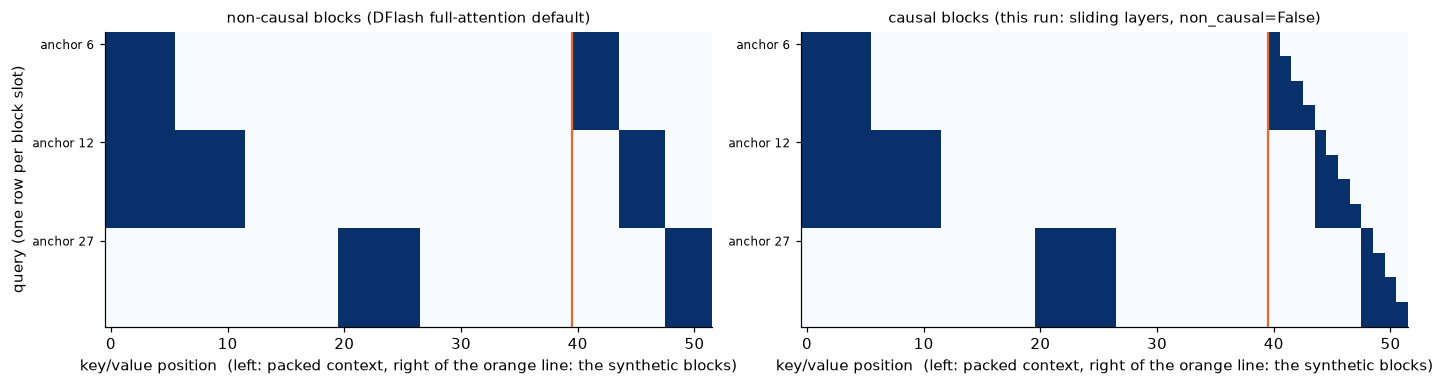

anchor 6 sees context 0..5 of doc 0; anchor 12 sees 0..11; anchor 27 sees 20..26 of doc 1 only (documents never mix).


In [11]:
def create_anchor_block_mask(document_ids, total_seq_len, anchor_positions, block_size, sliding_window=None, sliding_window_non_causal=False):
    """Dense boolean [Q, KV] version of create_anchor_block_mask_mod (True = may attend).
    Q  = num_anchors * block_size synthetic query tokens;  KV = [ packed context (T) | synthetic block tokens (Q) ]."""
    non_causal = sliding_window is None or sliding_window_non_causal            # full-attention layers use non-causal blocks
    dev = document_ids.device
    n_anchors = anchor_positions.numel(); Q = n_anchors * block_size; KV = total_seq_len + Q
    q_idx, kv_idx = torch.arange(Q, device=dev)[:, None], torch.arange(KV, device=dev)[None, :]
    q_anchor = torch.repeat_interleave(anchor_positions.to(dev), block_size)[q_idx]    # absolute position of this query's anchor  [Q,1]
    q_doc = document_ids[q_anchor]
    kv_is_base = kv_idx < total_seq_len
    kv_base_pos = torch.remainder(kv_idx, total_seq_len)
    kv_doc = document_ids[kv_base_pos]
    in_window = (kv_base_pos >= q_anchor - sliding_window) if sliding_window is not None else True
    base_prefix = kv_is_base & (q_doc == kv_doc) & (q_doc != -1) & (kv_base_pos < q_anchor) & in_window
    q_block, kv_block = q_idx // block_size, (kv_idx - total_seq_len) // block_size
    same_block = (kv_idx >= total_seq_len) & (q_block == kv_block)
    if not non_causal:
        same_block = same_block & (kv_idx <= q_idx + total_seq_len)
    return base_prefix | same_block

# a toy example: 2 documents of 20 tokens, 3 anchors, block size 4
T_toy, bs_toy = 40, 4
doc_toy = torch.tensor([0] * 20 + [1] * 20, device=device)
anc_toy = torch.tensor([6, 12, 27], device=device)
m = create_anchor_block_mask(doc_toy, T_toy, anc_toy, bs_toy, sliding_window=None, sliding_window_non_causal=True).cpu().numpy()
m_causal = create_anchor_block_mask(doc_toy, T_toy, anc_toy, bs_toy, sliding_window=2048, sliding_window_non_causal=False).cpu().numpy()

fig, axs = plt.subplots(1, 2, figsize=(13, 3.6))
for ax, mm, title in zip(axs, (m, m_causal), ("non-causal blocks (DFlash full-attention default)", "causal blocks (this run: sliding layers, non_causal=False)")):
    ax.imshow(mm, cmap="Blues", aspect="auto", interpolation="nearest"); ax.grid(False)
    ax.axvline(T_toy - 0.5, color=ORANGE, lw=1.5); ax.set_title(title, fontsize=10)
    ax.set_yticks(range(0, mm.shape[0], bs_toy)); ax.set_yticklabels([f"anchor {int(a)}" for a in anc_toy.cpu()], fontsize=8)
    ax.set_xlabel("key/value position  (left: packed context, right of the orange line: the synthetic blocks)")
axs[0].set_ylabel("query (one row per block slot)")
plt.tight_layout(); plt.show()
print("anchor 6 sees context 0..5 of doc 0; anchor 12 sees 0..11; anchor 27 sees 20..26 of doc 1 only (documents never mix).")

### 5.3 One draft decoder layer

Each layer is a Qwen3 decoder layer with one change in the attention. Normally keys/values are computed from the layer's own hidden states. Here the **keys/values for the context come from the
verifier's hidden states** (after a linear layer + norm), using the *same* `k_proj`/`v_proj` weights as the block tokens, and are concatenated in front of the block's own keys/values.
This is the "KV injection" the paper describes.

*Library reference: `models/dflash/model_definitions.py` (`Qwen3DFlashAttention`, `Qwen3DFlashDecoderLayer`). We use `F.scaled_dot_product_attention` with our dense mask where the library uses flex attention.*

In [12]:
def _rotate_half(x):
    x1, x2 = x[..., : x.shape[-1] // 2], x[..., x.shape[-1] // 2:]
    return torch.cat((-x2, x1), dim=-1)

def apply_rotary_pos_emb(q, k, cos, sin, unsqueeze_dim=1):
    cos, sin = cos.unsqueeze(unsqueeze_dim), sin.unsqueeze(unsqueeze_dim)
    q_len = q.size(-2)
    q_embed = (q * cos[..., -q_len:, :]) + (_rotate_half(q) * sin[..., -q_len:, :])   # queries are the LAST q_len positions
    k_embed = (k * cos) + (_rotate_half(k) * sin)                                      # keys cover context + block
    return q_embed, k_embed

class DraftAttention(nn.Module):
    """Mirrors Qwen3DFlashAttention: K/V = [ proj(verifier context) ; proj(block hidden) ]."""
    def __init__(self, config):
        super().__init__()
        self.head_dim = config.head_dim
        self.scaling = self.head_dim ** -0.5
        H, nh, nkv, hd = config.hidden_size, config.num_attention_heads, config.num_key_value_heads, config.head_dim
        self.q_proj, self.k_proj = nn.Linear(H, nh * hd, bias=False), nn.Linear(H, nkv * hd, bias=False)
        self.v_proj, self.o_proj = nn.Linear(H, nkv * hd, bias=False), nn.Linear(nh * hd, H, bias=False)
        self.q_norm, self.k_norm = Qwen3RMSNorm(hd, eps=config.rms_norm_eps), Qwen3RMSNorm(hd, eps=config.rms_norm_eps)

    def forward(self, hidden_states, target_hidden, cos, sin, attn_mask):
        bsz, q_len = hidden_states.shape[:-1]
        ctx_len = target_hidden.shape[1]
        q = self.q_norm(self.q_proj(hidden_states).view(bsz, q_len, -1, self.head_dim)).transpose(1, 2)
        k_ctx, k_noise = self.k_proj(target_hidden), self.k_proj(hidden_states)       # <- the main difference from a normal attention
        v_ctx, v_noise = self.v_proj(target_hidden), self.v_proj(hidden_states)
        k = torch.cat([k_ctx, k_noise], dim=1).view(bsz, ctx_len + q_len, -1, self.head_dim)
        v = torch.cat([v_ctx, v_noise], dim=1).view(bsz, ctx_len + q_len, -1, self.head_dim)
        k, v = self.k_norm(k).transpose(1, 2), v.transpose(1, 2)
        q, k = apply_rotary_pos_emb(q, k, cos, sin)
        out = F.scaled_dot_product_attention(q, k, v, attn_mask=attn_mask, scale=self.scaling, enable_gqa=True)
        return self.o_proj(out.transpose(1, 2).reshape(bsz, q_len, -1))

class DraftLayer(nn.Module):
    """Mirrors Qwen3DFlashDecoderLayer: pre-norm attention + pre-norm MLP, target_hidden is passed through untouched."""
    def __init__(self, config):
        super().__init__()
        self.self_attn, self.mlp = DraftAttention(config), Qwen3MLP(config)
        self.input_layernorm = Qwen3RMSNorm(config.hidden_size, eps=config.rms_norm_eps)
        self.post_attention_layernorm = Qwen3RMSNorm(config.hidden_size, eps=config.rms_norm_eps)

    def forward(self, hidden_states, target_hidden, cos, sin, attn_mask):
        hidden_states = hidden_states + self.self_attn(self.input_layernorm(hidden_states), target_hidden, cos, sin, attn_mask)
        return hidden_states + self.mlp(self.post_attention_layernorm(hidden_states))

# the draft's transformer config = the verifier's config with 3 layers, all "sliding_attention" (train/cli.py::create_transformer_layer_config)
draft_cfg = copy.deepcopy(verifier_cfg)
draft_cfg.num_hidden_layers = NUM_LAYERS
draft_cfg.layer_types = ["sliding_attention"] * NUM_LAYERS
draft_cfg.sliding_window, draft_cfg.use_sliding_window = 2048, True
print(f"one draft layer: {sum(p.numel() for p in DraftLayer(draft_cfg).parameters())/1e6:.2f}M parameters "
      f"(hidden {draft_cfg.hidden_size}, {draft_cfg.num_attention_heads} heads / {draft_cfg.num_key_value_heads} KV heads, head_dim {draft_cfg.head_dim}, MLP {draft_cfg.intermediate_size})")

one draft layer: 15.73M parameters (hidden 1024, 16 heads / 8 KV heads, head_dim 128, MLP 3072)


### 5.4 The Markov head and the confidence head

**Markov head.** The bias for slot *k* depends on the token just before it, `x_{k-1}`: `B(x_{k-1}, .) = W2( W1[x_{k-1}] )`. `W1` is an embedding table over the **verifier** vocabulary
(151,936 x 256), `W2` projects the 256-dim vector to the **draft** vocabulary (256 -> 32,000). It is a rank-256 factorisation of a full "previous token -> next token" bigram matrix
(which would have 4.9 billion entries). The result is *added to the logits*. In `vanilla` mode that is all; `gated` and `rnn` use the backbone hidden state too (the paper describes `vanilla` as the default and an RNN variant as a marginal gain).

**Confidence head.** One linear layer on `[hidden state of the slot ; W1[previous token]]` giving a probability. Its training label is the analytical acceptance rate of that slot (defined in section 6).

*Library reference: `models/dspark/model_definitions.py` (`MarkovHead`, `ConfidenceHead`).*

In [13]:
class MarkovHead(nn.Module):
    """Low-rank sequential logit bias B = W1 @ W2. W1 indexes the VERIFIER vocab (previous token id); W2 projects to the DRAFT vocab."""
    def __init__(self, *, verifier_vocab_size, draft_vocab_size, markov_rank, hidden_size, head_type="vanilla"):
        super().__init__()
        self.head_type, self.markov_rank = head_type, markov_rank
        self.markov_w1 = nn.Embedding(verifier_vocab_size, markov_rank)
        nn.init.normal_(self.markov_w1.weight, std=0.01)
        self.markov_w2 = nn.Linear(markov_rank, draft_vocab_size, bias=False)
        if head_type == "gated":   self.gate_proj = nn.Linear(hidden_size + markov_rank, markov_rank)
        elif head_type == "rnn":   self.joint_proj = nn.Linear(2 * markov_rank + hidden_size, 3 * markov_rank)

    def prev_embeddings(self, token_ids):
        return self.markov_w1(token_ids.long())

    def block_bias(self, *, prev_token_ids, hidden_states, prev_emb=None):
        """prev_token_ids [N, block], hidden_states [N, block, H] -> bias [N, block, draft_vocab]."""
        if prev_emb is None: prev_emb = self.prev_embeddings(prev_token_ids)
        prev_emb = prev_emb.to(self.markov_w2.weight.dtype)
        if self.head_type == "vanilla":
            return self.markov_w2(prev_emb)
        if self.head_type == "gated":
            hidden_states = hidden_states.to(prev_emb.dtype)
            gate = torch.sigmoid(self.gate_proj(torch.cat([hidden_states, prev_emb], dim=-1)))
            return self.markov_w2(gate * prev_emb)
        hidden_states = hidden_states.to(prev_emb.dtype)                      # rnn: a recurrent state over the block
        num_blocks, block_size, _ = prev_emb.shape
        state, outputs = prev_emb.new_zeros(num_blocks, self.markov_rank), []
        for k in range(block_size):
            z = torch.cat([state, prev_emb[:, k], hidden_states[:, k]], dim=-1)
            gate_raw, cand_raw, out_raw = self.joint_proj(z).chunk(3, dim=-1)
            gate = torch.sigmoid(gate_raw)
            state = gate * state + (1.0 - gate) * torch.tanh(cand_raw)
            outputs.append(self.markov_w2(torch.tanh(out_raw)))
        return torch.stack(outputs, dim=1)

class ConfidenceHead(nn.Module):
    """Per-position acceptance-probability predictor (linear -> scalar logit)."""
    def __init__(self, input_dim):
        super().__init__()
        self.proj = nn.Linear(input_dim, 1)
    def forward(self, features):
        return self.proj(features).squeeze(-1)

mh = MarkovHead(verifier_vocab_size=verifier_cfg.vocab_size, draft_vocab_size=DRAFT_VOCAB_SIZE, markov_rank=MARKOV_RANK, hidden_size=1024)
print(f"Markov head: W1 {tuple(mh.markov_w1.weight.shape)} = {mh.markov_w1.weight.numel()/1e6:.1f}M, W2 {tuple(mh.markov_w2.weight.shape)} = {mh.markov_w2.weight.numel()/1e6:.1f}M"
      f"  vs. a full bigram matrix: {verifier_cfg.vocab_size*DRAFT_VOCAB_SIZE/1e9:.1f}B entries")

Markov head: W1 (151936, 256) = 38.9M, W2 (32000, 256) = 8.2M  vs. a full bigram matrix: 4.9B entries


### 5.5 Putting it together: `DSparkDraft`

The forward pass has two halves. `_backbone_forward` (from DFlash) builds the anchor blocks, the mask, runs the layers and returns draft logits `U` plus the verifier's **targets** at the same positions.
The DSpark part then adds the Markov bias to `U` (using the *real* previous tokens: this is teacher forcing) and computes the confidence logits.
Parameter names are identical to the library's, so we can load the real checkpoint into this class in §9.

Frozen vs trained: `embed_tokens`, `lm_head` (the verifier's rows selected by `t2d`) and the verifier's final norm/LM head used for targets are **frozen**; everything else trains.

*Library reference: `models/dflash/core.py` (`DFlashDraftModel._backbone_forward`), `models/dspark/core.py` (`DSparkDraftModel.forward`), `model.py` (`DraftVocabMixin`, `_load_verifier_weights`).*

In [14]:
class DSparkDraft(nn.Module):
    def __init__(self, config, *, block_size=BLOCK_SIZE, target_layer_ids=TARGET_LAYER_IDS, draft_vocab_size=DRAFT_VOCAB_SIZE,
                 markov_rank=MARKOV_RANK, markov_head_type=MARKOV_HEAD_TYPE, mask_token_id=MASK_ID, sample_from_anchor=True):
        super().__init__()
        self.config, self.block_size, self.mask_token_id = config, block_size, mask_token_id
        self.sample_from_anchor, self.sliding_window = sample_from_anchor, config.sliding_window
        H = config.hidden_size
        # --- vocab + frozen verifier-owned pieces (DraftVocabMixin) ---
        self.register_buffer("t2d", torch.zeros(config.vocab_size, dtype=torch.bool))
        self.register_buffer("d2t", torch.zeros(draft_vocab_size, dtype=torch.long))
        self.embed_tokens = nn.Embedding(config.vocab_size, H)                    # verifier's embedding table (frozen, not saved)
        self.lm_head = nn.Linear(H, draft_vocab_size, bias=False)                 # verifier lm_head rows selected by t2d (frozen, saved)
        self.verifier_lm_head = nn.Linear(H, draft_vocab_size, bias=False)        # same rows, used for the targets (frozen, not saved)
        self.verifier_norm = Qwen3RMSNorm(H, eps=config.rms_norm_eps)
        for m in (self.embed_tokens, self.lm_head, self.verifier_lm_head, self.verifier_norm):
            for p in m.parameters(): p.requires_grad_(False)
        # --- trainable draft ---
        self.layers = nn.ModuleList([DraftLayer(config) for _ in range(config.num_hidden_layers)])
        self.fc = nn.Linear(len(target_layer_ids) * H, H, bias=False)             # fuses layers 2,14,25 into the context features
        self.hidden_norm = Qwen3RMSNorm(H, eps=config.rms_norm_eps)
        self.norm = Qwen3RMSNorm(H, eps=config.rms_norm_eps)
        self.rotary_emb = Qwen3RotaryEmbedding(config)
        self.markov_head = MarkovHead(verifier_vocab_size=config.vocab_size, draft_vocab_size=draft_vocab_size,
                                      markov_rank=markov_rank, hidden_size=H, head_type=markov_head_type)
        self.confidence_head = ConfidenceHead(H + markov_rank)                    # confidence_head_with_markov=True
        for n, mod in self.named_modules():                                       # HF-style init for the trainable linears
            if isinstance(mod, nn.Linear) and mod.weight.requires_grad and "markov" not in n:
                nn.init.normal_(mod.weight, std=config.initializer_range)
                if mod.bias is not None: nn.init.zeros_(mod.bias)

    @torch.no_grad()
    def load_verifier_weights(self, verifier_model, t2d, d2t):
        """Mirrors model.py::_load_verifier_weights: copy embeddings / lm_head rows / final norm from the verifier."""
        self.t2d.copy_(t2d), self.d2t.copy_(d2t)
        self.embed_tokens.weight.copy_(verifier_model.model.embed_tokens.weight)
        head = verifier_model.lm_head.weight[t2d.to(verifier_model.lm_head.weight.device)]          # [32000, H]
        self.lm_head.weight.copy_(head); self.verifier_lm_head.weight.copy_(head)
        self.verifier_norm.weight.copy_(verifier_model.model.norm.weight)

    def _backbone_forward(self, hidden_states, input_ids, loss_mask, verifier_last_hidden_states, document_ids, position_ids,
                          max_anchors, anchor_positions=None, compute_targets=True):
        device_, T = hidden_states.device, hidden_states.shape[1]
        if anchor_positions is None:
            anchor_positions, anchor_valid = select_anchors(loss_mask, max_anchors, self.block_size)
        else:
            anchor_valid = torch.ones_like(anchor_positions, dtype=torch.bool)
        A, bs = anchor_positions.numel(), self.block_size
        attn_mask = create_anchor_block_mask(document_ids[0], T, anchor_positions, bs, sliding_window=self.sliding_window)[None, None]

        mask_token_ids = torch.full((1, A * bs), self.mask_token_id, dtype=torch.long, device=device_)
        mask_token_ids[:, ::bs] = input_ids[:, anchor_positions]                    # slot 0 = the real anchor token, slots 1.. = <|MASK|>
        noise_embedding = self.embed_tokens(mask_token_ids)                         # [1, A*bs, H]
        fc_output = self.hidden_norm(self.fc(hidden_states))                        # [1, T, H]  context features from layers 2,14,25

        mask_position_ids = get_base_indices_for_anchored_blocks(position_ids[0, anchor_positions], bs)
        position_ids = torch.cat([position_ids, mask_position_ids.unsqueeze(0)], dim=1)       # [1, T + A*bs]
        cos, sin = self.rotary_emb(hidden_states, position_ids)
        anchored_block_indices = get_base_indices_for_anchored_blocks(anchor_positions, bs)    # [A*bs] absolute positions

        targets = None
        if compute_targets:
            with torch.no_grad():   # verifier's distribution over the draft vocab at positions anchor, anchor+1, ...
                targets = self.verifier_lm_head(self.verifier_norm(verifier_last_hidden_states[:, anchored_block_indices]))
        for layer in self.layers:
            noise_embedding = layer(noise_embedding, fc_output, cos, sin, attn_mask)
        hidden = self.norm(noise_embedding)
        logits = self.lm_head(hidden)                                                # [1, A*bs, draft_vocab]
        aligned_loss_mask = loss_mask[:, anchored_block_indices].float() * anchor_valid.repeat_interleave(bs).unsqueeze(0).float()
        return hidden, logits, targets, aligned_loss_mask, anchored_block_indices

    def forward(self, hidden_states, input_ids, loss_mask, last_hs, document_ids, position_ids, max_anchors=MAX_ANCHORS,
                use_markov=True, return_tensors=False):
        hidden, logits, targets, aligned_loss_mask, block_idx = self._backbone_forward(
            hidden_states, input_ids, loss_mask, last_hs, document_ids, position_ids, max_anchors)
        A, bs = max_anchors, self.block_size
        block_tokens = input_ids[0, block_idx].view(A, bs)                           # ground-truth tokens at anchor+0 .. anchor+bs-1
        prev_token_ids = block_tokens if self.sample_from_anchor else torch.cat([block_tokens[:, :1], block_tokens[:, :-1]], dim=1)
        hidden_blocks = hidden.view(A, bs, -1)
        prev_emb = self.markov_head.prev_embeddings(prev_token_ids)
        if use_markov:   # slot k's bias is conditioned on the REAL token at anchor+k  (teacher forcing)
            markov_bias = self.markov_head.block_bias(prev_token_ids=prev_token_ids, hidden_states=hidden_blocks, prev_emb=prev_emb)
            logits = (logits.view(A, bs, -1) + markov_bias).view(1, A * bs, -1)
        conf_features = torch.cat([hidden_blocks, prev_emb.to(hidden_blocks.dtype)], dim=-1)
        confidence_logits = self.confidence_head(conf_features).reshape(1, A * bs)
        loss, metrics = compute_metrics(logits, targets, confidence_logits, aligned_loss_mask, bs)
        if return_tensors: metrics["_tensors"] = dict(logits=logits, targets=targets, conf=confidence_logits, mask=aligned_loss_mask, block_idx=block_idx)
        return loss, metrics

draft = DSparkDraft(draft_cfg).to(device)
draft.load_verifier_weights(verifier, t2d, d2t)
n_train = sum(p.numel() for p in draft.parameters() if p.requires_grad); n_frozen = sum(p.numel() for p in draft.parameters() if not p.requires_grad)
print(f"trainable: {n_train/1e6:.1f}M | frozen (verifier-owned, incl. the embedding table): {n_frozen/1e6:.1f}M")
print("parameters that are SAVED in a checkpoint (everything except embed_tokens and the verifier_* copies):",
      f"{(sum(p.numel() for n, p in draft.named_parameters() if not n.startswith(('embed_tokens', 'verifier_'))))/1e6:.2f}M",
      "<- the trained checkpoint has 130.20M weights")

trainable: 97.4M | frozen (verifier-owned, incl. the embedding table): 221.1M
parameters that are SAVED in a checkpoint (everything except embed_tokens and the verifier_* copies): 130.20M <- the trained checkpoint has 130.20M weights


## 6. The loss and the metrics

For every slot of every block we have two distributions over the 32,000 draft tokens: the **verifier's** `p` (the target) and the **drafter's** `q` (its softmax, Markov bias included).

**Acceptance rate.** In speculative sampling a draft token is accepted with probability `min(1, p(x)/q(x))`, which averages out to the *overlap* of the two distributions:

$$\alpha_k = \sum_v \min\big(p_k(v), q_k(v)\big) = 1 - \mathrm{TV}(p_k, q_k)$$

So the total-variation distance `TV` is a **direct, differentiable proxy for acceptance**. That is why the loss uses it.

**Loss.** Three terms, each averaged over trained slots with a position weight `w_k = exp(-k / gamma)` that favours early slots (a miss at slot 0 invalidates the whole block):

$$\mathcal{L} = 0.1\,\mathcal{L}_{\mathrm{CE}} \;+\; 0.9\,\mathcal{L}_{\mathrm{TV}} \;+\; 1.0\,\mathcal{L}_{\mathrm{conf}}$$

`CE`: cross-entropy against the verifier's *argmax* token. `TV`: `1 - alpha` above. `conf`: binary cross-entropy training the confidence head to output `alpha` for each slot.

**Metrics** (all *teacher-forced*: computed from one forward pass on real text, no generation):

* `accept_len` $= 1 + \sum_{j=0}^{K-1} \prod_{i=0}^{j} \alpha_i$ per block: the *expected* number of tokens per verifier step, if slot *j* is accepted only when all earlier slots were (the `1` is the verifier's bonus token). Averaged over blocks.
* `eal` (greedy): $1 + $ the length of the leading run of slots whose **argmax** equals the verifier's argmax. Same shape, but with a 0/1 indicator in place of $\alpha$.

*Library reference: `models/dspark/metrics.py` (`compute_metrics`), `models/metrics.py` (`compute_accepted_length_counts`, `compute_accuracy_multi_step`), `losses/utils.py` (`compound_loss`, `loss_function`, `dflash_loss_decay`), `losses/eager.py` (`tv_loss`, `ce_loss`).*

In [15]:
def tv_loss(logits, targets):
    """Per-position TV distance = 1 - sum_v min(p_v, q_v)   (losses/eager.py::tv_loss)."""
    draft_p = F.softmax(logits, dim=-1, dtype=torch.float32)
    target_p = F.softmax(targets, dim=-1, dtype=torch.float32)
    return 1.0 - torch.minimum(draft_p, target_p).sum(dim=-1)                     # [1, T]

def ce_loss(logits, targets):
    """Cross-entropy against the argmax of the verifier's logits   (losses/eager.py::ce_loss)."""
    B, T, V = logits.shape
    return F.cross_entropy(logits.reshape(-1, V).float(), targets.argmax(-1).reshape(-1), reduction="none").reshape(B, T)

def dflash_loss_decay(pos_idx, gamma, **_):
    """sample_from_anchor=True (DSpark): slot 0 has weight 1, then exp(-k/gamma)   (losses/utils.py::dflash_loss_decay)."""
    return torch.exp(-pos_idx / gamma)

def loss_function(logits, targets, loss_mask, pos_idx, loss_fn, decay_fn=None):
    """Masked, position-weighted mean of a per-position loss   (losses/utils.py::loss_function)."""
    elementwise = loss_fn(logits, targets) * loss_mask.to(torch.float32)
    if decay_fn is not None: elementwise = elementwise * decay_fn(pos_idx.to(elementwise.dtype))
    return (elementwise.sum(dim=1) / (loss_mask.sum(dim=1) + 1e-5)).mean()

def compound_loss(logits, targets, loss_mask, pos_idx, loss_config, decay_fn=None):
    """sum_i weight_i * term_i   (losses/utils.py::compound_loss)."""
    total, terms = torch.tensor(0.0, device=logits.device), {}
    for name, (fn, weight) in loss_config.items():
        term = loss_function(logits, targets, loss_mask, pos_idx, fn, decay_fn)
        terms[f"{name}_loss"] = term.detach(); total = total + weight * term
    return total, terms

LOSS_CONFIG = {"ce": (ce_loss, LOSS_WEIGHTS["ce"]), "tv": (tv_loss, LOSS_WEIGHTS["tv"])}

def compute_accepted_length_counts(correct, valid):
    """Leading run of correct slots + 1 bonus token, per block   (models/metrics.py)."""
    accepted = torch.logical_and(correct, valid).to(torch.float32)
    per_block_len = accepted.cumprod(dim=-1).sum(dim=-1) + 1.0
    block_valid = valid.any(dim=-1).to(torch.float32)
    return (per_block_len * block_valid).sum(), block_valid.sum()

def compute_metrics(logits, targets, confidence_logits, loss_mask, block_size, gamma=GAMMA, confidence_head_alpha=CONF_ALPHA):
    """Mirrors models/dspark/metrics.py::compute_metrics (sample_from_anchor=True). Returns the loss and *_sum / *_total pairs."""
    T = logits.shape[1]
    pos_idx = (torch.arange(T, device=logits.device) % block_size).unsqueeze(0)
    decay_fn = lambda pos, **_: dflash_loss_decay(pos, gamma)
    loss, term_losses = compound_loss(logits, targets, loss_mask, pos_idx, LOSS_CONFIG, decay_fn)

    with torch.no_grad():
        accept_rate = 1.0 - tv_loss(logits, targets)                                  # alpha per slot   [1, T]
        num_blocks = T // block_size
        draft_mask = loss_mask.to(accept_rate.dtype).view(num_blocks, block_size)
        accept_prefix = (accept_rate.view(num_blocks, block_size) * draft_mask).cumprod(dim=-1)   # prod_{i<=j} alpha_i

    # confidence head: BCE against alpha, same masking/decay
    c_star = accept_rate.detach().to(confidence_logits.dtype)
    bce = F.binary_cross_entropy_with_logits(confidence_logits, c_star, reduction="none")
    conf_loss = (bce * loss_mask * decay_fn(pos_idx.to(bce.dtype))).sum(dim=1) / (loss_mask.sum(dim=1) + 1e-8)
    loss = loss + confidence_head_alpha * conf_loss.mean()

    m, ones = {}, torch.ones((), device=logits.device)
    mask_f = loss_mask.to(accept_rate.dtype)
    with torch.no_grad():
        conf_prob = confidence_logits.float().sigmoid()
        m["confidence_abs_error_sum"], m["confidence_abs_error_total"] = ((conf_prob - accept_rate).abs() * mask_f).sum(), mask_f.sum().clamp_min(1.0)
        m["accept_rate_sum"], m["accept_rate_total"] = (accept_rate * mask_f).sum(), mask_f.sum().clamp_min(1.0)
        per_block_len = accept_prefix.sum(dim=-1) + 1.0                                # tau = 1 + sum_j prod_{i<=j} alpha_i
        block_valid = (draft_mask.sum(dim=-1) > 0).to(accept_rate.dtype)
        m["accept_len_sum"], m["accept_len_total"] = (per_block_len * block_valid).sum(), block_valid.sum().clamp_min(1.0)
        pred_ids, target_ids = logits.argmax(-1), targets.argmax(-1)                  # greedy accuracy per slot
        correct = ((pred_ids == target_ids) & loss_mask.bool()).reshape(num_blocks, block_size)
        for k in range(block_size):
            m[f"position_{k}_acc_sum"], m[f"position_{k}_acc_total"] = correct[:, k].float().sum(), loss_mask.reshape(num_blocks, block_size)[:, k].sum().clamp_min(1.0)
        m["eal_sum"], m["eal_total"] = compute_accepted_length_counts((pred_ids == target_ids).reshape(num_blocks, block_size), draft_mask.to(torch.bool))
    m["loss_sum"], m["loss_total"] = loss.detach().clone(), ones
    for name, v in term_losses.items(): m[f"{name}_sum"], m[f"{name}_total"] = v, ones.clone()
    m["confidence_loss_sum"], m["confidence_loss_total"] = conf_loss.mean().detach(), ones.clone()
    return loss, m

def summarize(m):
    """Turn *_sum / *_total pairs into plain floats (what the trainer does after the all-reduce)."""
    return {k[:-4]: (m[k].item() / max(m[k[:-4] + "_total"].item(), 1e-9)) for k in m if k.endswith("_sum")}

**Work one example by hand.** Suppose a block's slots have acceptance rates `[0.9, 0.8, 0.5]` (3 slots for brevity). Then the survival probabilities are `0.9`, `0.9x0.8 = 0.72`, `0.72x0.5 = 0.36`,
so `accept_len = 1 + 0.9 + 0.72 + 0.36 = 2.98`. If the argmaxes matched in slots 0 and 1 but not 2, `eal = 1 + 2 = 3`.

survival: [0.8999999761581421, 0.7199999690055847, 0.35999998450279236] -> accept_len = 2.9799998998641968
greedy matches [True, True, False] -> eal = 3.0


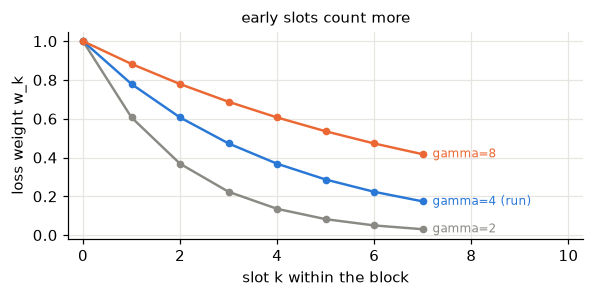

In [16]:
alpha = torch.tensor([[0.9, 0.8, 0.5]])
survival = alpha.cumprod(-1)
print("survival:", survival.tolist()[0], "-> accept_len =", 1 + survival.sum().item())
correct = torch.tensor([[True, True, False]])
print("greedy matches", correct.tolist()[0], "-> eal =", compute_accepted_length_counts(correct, torch.ones_like(correct))[0].item())

# the position weights w_k = exp(-k/gamma) and what GAMMA does
fig, ax = plt.subplots(figsize=(5.5, 2.8))
for g, c in ((2.0, GREY), (4.0, BLUE), (8.0, ORANGE)):
    ax.plot(range(BLOCK_SIZE), np.exp(-np.arange(BLOCK_SIZE) / g), marker="o", ms=4, color=c)
    ax.text(BLOCK_SIZE - 0.8, np.exp(-(BLOCK_SIZE - 1) / g), f"gamma={g:g}" + (" (run)" if g == 4 else ""), color=c, fontsize=8, ha="left", va="center")
ax.set_xlim(-0.3, 10.3); ax.set_xlabel("slot k within the block"); ax.set_ylabel("loss weight w_k"); ax.set_title("early slots count more", fontsize=10); plt.tight_layout(); plt.show()

**Check our metrics against the library.** The `speculators` package is installed in this environment, so we can feed the *same* tensors to its real `compute_metrics` and compare.
(One forward pass of the untrained drafter on a real packed sequence; the numbers themselves are meaningless at this point, they just have to agree.)

In [17]:
batch = make_batches(train_rows, SEQ_LENGTH)[0]
torch.manual_seed(0)
with torch.no_grad(), torch.autocast("cuda", dtype=torch.bfloat16):
    loss0, m0 = draft(batch["hidden_states"], batch["input_ids"], batch["loss_mask"], batch["last_hs"], batch["document_ids"], batch["position_ids"], return_tensors=True)
T0 = m0.pop("_tensors")
print({k: round(v, 4) for k, v in summarize(m0).items() if k in ("loss", "accept_len", "eal", "accept_rate")})
try:
    from speculators.models.dspark.metrics import compute_metrics as lib_compute_metrics
    from speculators.losses import resolve_loss_config
    lib_cfg = resolve_loss_config(json.dumps(LOSS_WEIGHTS), "eager"); lib_tv = resolve_loss_config("tv", "eager")["tv"][0]
    with torch.autocast("cuda", dtype=torch.bfloat16):   # as inside the trainer: the library's CE runs on bf16 logits and autocasts to fp32
        lib_loss, lib_m = lib_compute_metrics(T0["logits"], T0["targets"], T0["conf"], T0["mask"], BLOCK_SIZE, loss_config=lib_cfg, tv_loss_fn=lib_tv,
                                              gamma=GAMMA, confidence_head_alpha=CONF_ALPHA, sample_from_anchor=True)
    ours, theirs = summarize(m0), {k[:-4]: lib_m[k].item() / max(lib_m[k[:-4] + "_total"].item(), 1e-9) for k in lib_m if k.endswith("_sum")}
    print(f"\n{'metric':22s}{'ours':>12s}{'library':>12s}")
    for k in ("loss", "ce_loss", "tv_loss", "accept_rate", "accept_len", "eal", "position_0_acc", "confidence_abs_error"):
        print(f"{k:22s}{ours[k]:12.5f}{theirs[k]:12.5f}")
    print("\nmatch:", all(abs(ours[k] - theirs[k]) < 1e-3 * max(1, abs(theirs[k])) for k in ("loss", "ce_loss", "accept_len", "eal", "accept_rate", "tv_loss", "position_0_acc")))
except Exception as e:
    print("library comparison skipped:", type(e).__name__, e)

{'accept_rate': 0.0008, 'accept_len': 1.0008, 'eal': 1.0, 'loss': 1.1479}



metric                        ours     library
loss                       1.14786     1.14784
ce_loss                    5.08713     5.08688
tv_loss                    0.48909     0.48909
accept_rate                0.00079     0.00079
accept_len                 1.00083     1.00083
eal                        1.00000     1.00000
position_0_acc             0.00000     0.00000
confidence_abs_error       0.33159     0.33159

match: True


## 7. Training (what the trainer does each step)

Per step (`train/trainer.py::train_epoch`): take one packed sequence, add noise to the context hidden states, run the forward pass under bf16 autocast (fp32 master weights),
backpropagate, **clip the gradient norm to 1.0**, step the optimisers, step the LR schedulers.

**Optimiser.** The run uses **Muon** for the 2-D weight matrices of the draft layers and `fc`, and **AdamW** for everything else (norm weights, the confidence head, and the Markov
and LM-head matrices, which Muon's convention excludes). Both use LR `3e-4`. Muon: momentum 0.95, weight decay 0.1, 5 Newton-Schulz steps, `match_rms_adamw` scaling. AdamW: weight decay 0.01.
**Schedule:** linear warm-up over the first 1% of steps, then linear decay to 0 (one scheduler per optimiser).

*Library reference: `train/optimizers.py` (`split_named_params_for_muon`, `build_optimizers`), `train/trainer.py` (`train_epoch`, schedulers), `train/config/schema.py` (defaults).*

In [18]:
from transformers import get_linear_schedule_with_warmup
_ADAMW_NAME_HINTS = ("embed_tokens", "lm_head", "codebook", "markov_w1", "markov_w2")

def split_named_params_for_muon(model):
    """A param goes to Muon iff it is a trainable 2-D matrix and not an embedding / output head / Markov factor."""
    muon, adamw = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad: continue
        if p.ndim == 2 and min(p.shape) > 1 and not any(h in name for h in _ADAMW_NAME_HINTS): muon.append((name, p))
        else: adamw.append((name, p))
    return muon, adamw

def build_optimizers(model, lr=LR):
    muon, adamw = split_named_params_for_muon(model)
    opts = [torch.optim.Muon(muon, lr=lr, momentum=0.95, weight_decay=0.1, ns_steps=5, adjust_lr_fn="match_rms_adamw"),
            torch.optim.AdamW(adamw, lr=lr, weight_decay=0.01)]
    return opts, muon, adamw

@torch.no_grad()
def evaluate(model, rows_, n_draws=3, **fwd_kw):
    """Teacher-forced metrics on held-out rows; anchors are random, so average a few draws (no noise at validation)."""
    model.eval(); agg = Counter()
    for _ in range(n_draws):
        for b in make_batches(rows_, SEQ_LENGTH):
            with torch.autocast("cuda", dtype=torch.bfloat16):
                _, m = model(b["hidden_states"], b["input_ids"], b["loss_mask"], b["last_hs"], b["document_ids"], b["position_ids"], **fwd_kw)
            for k, v in m.items(): agg[k] += v.item()
    return {k[:-4]: agg[k] / max(agg[k[:-4] + "_total"], 1e-9) for k in agg if k.endswith("_sum")}

def train(model, train_rows_, val_rows_, steps, log_every=10, eval_every=50, seed=SEED):
    opts, muon, adamw = build_optimizers(model)
    warmup = max(1, steps // 100)
    scheds = [get_linear_schedule_with_warmup(o, num_warmup_steps=warmup, num_training_steps=steps) for o in opts]
    print(f"Muon: {len(muon)} matrices ({sum(p.numel() for _, p in muon)/1e6:.1f}M) | AdamW: {len(adamw)} tensors ({sum(p.numel() for _, p in adamw)/1e6:.1f}M) | warm-up {warmup} steps")
    hist = dict(step=[], loss=[], accept_len=[], eal=[], val_step=[], val_loss=[], val_accept_len=[], val_eal=[])
    step, epoch = 0, 0
    while step < steps:
        model.train()
        for b in make_batches(train_rows_, SEQ_LENGTH, shuffle=True, seed=seed + epoch):     # a fresh packing each epoch
            if step >= steps: break
            hs = add_uniform_noise(b["hidden_states"])                                         # noise on the context layers only
            with torch.autocast("cuda", dtype=torch.bfloat16):
                loss, m = model(hs, b["input_ids"], b["loss_mask"], b["last_hs"], b["document_ids"], b["position_ids"])
            for o in opts: o.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            for o in opts: o.step()
            for s in scheds: s.step()
            if step % log_every == 0:
                s_ = summarize(m); hist["step"].append(step); [hist[k].append(s_[k]) for k in ("loss", "accept_len", "eal")]
            if step % eval_every == 0 or step == steps - 1:
                v = evaluate(model, val_rows_); model.train()
                hist["val_step"].append(step); hist["val_loss"].append(v["loss"]); hist["val_accept_len"].append(v["accept_len"]); hist["val_eal"].append(v["eal"])
                print(f"step {step:4d} | train loss {summarize(m)['loss']:.3f} accept_len {summarize(m)['accept_len']:.2f} eal {summarize(m)['eal']:.2f}"
                      f" | val loss {v['loss']:.3f} accept_len {v['accept_len']:.2f} eal {v['eal']:.2f}")
            step += 1
        epoch += 1
    return hist

untrained_val = evaluate(draft, val_rows)
print("before training, on the held-out rows:", {k: round(untrained_val[k], 3) for k in ("loss", "accept_len", "eal")})

before training, on the held-out rows: {'loss': 1.224, 'accept_len': 1.001, 'eal': 1.0}


In [19]:
t0 = time.time()
hist = train(draft, train_rows, val_rows, TRAIN_STEPS)
print(f"\ntrained {TRAIN_STEPS} steps in {time.time()-t0:.0f}s")

Muon: 22 matrices (50.3M) | AdamW: 18 tensors (47.1M) | warm-up 6 steps


step    0 | train loss 1.170 accept_len 1.00 eal 1.00 | val loss 1.226 accept_len 1.00 eal 1.00


step   50 | train loss 0.800 accept_len 1.04 eal 1.05 | val loss 0.808 accept_len 1.04 eal 1.11


step  100 | train loss 0.777 accept_len 1.16 eal 1.24 | val loss 0.819 accept_len 1.13 eal 1.14


step  150 | train loss 0.755 accept_len 1.36 eal 1.46 | val loss 0.825 accept_len 1.20 eal 1.20


...

step  400 | train loss 0.414 accept_len 3.43 eal 5.65 | val loss 1.269 accept_len 1.22 eal 1.28


step  450 | train loss 0.265 accept_len 4.98 eal 8.06 | val loss 1.411 accept_len 1.20 eal 1.28


step  500 | train loss 0.284 accept_len 4.82 eal 7.81 | val loss 1.579 accept_len 1.16 eal 1.22


step  550 | train loss 0.316 accept_len 4.31 eal 7.57 | val loss 1.629 accept_len 1.18 eal 1.24


step  599 | train loss 0.250 accept_len 5.21 eal 8.32 | val loss 1.688 accept_len 1.19 eal 1.21

trained 600 steps in 18s


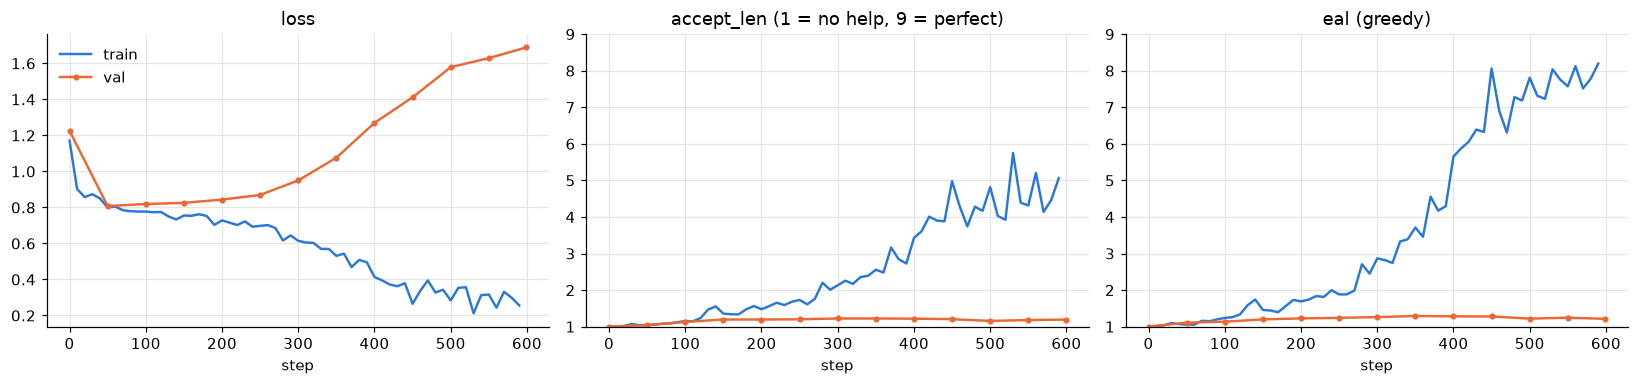

The gap between the train curve and the val points is overfitting: with ~20 rows the drafter memorises its training text.


In [20]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3.6))
axs[0].plot(hist["step"], hist["loss"], color=BLUE, label="train"); axs[0].plot(hist["val_step"], hist["val_loss"], color=ORANGE, marker="o", ms=3, label="val")
axs[0].set_title("loss"); axs[0].set_xlabel("step"); axs[0].legend(frameon=False)
axs[1].plot(hist["step"], hist["accept_len"], color=BLUE); axs[1].plot(hist["val_step"], hist["val_accept_len"], color=ORANGE, marker="o", ms=3)
axs[1].set_title("accept_len (1 = no help, 9 = perfect)"); axs[1].set_xlabel("step"); axs[1].set_ylim(1, 9)
axs[2].plot(hist["step"], hist["eal"], color=BLUE); axs[2].plot(hist["val_step"], hist["val_eal"], color=ORANGE, marker="o", ms=3)
axs[2].set_title("eal (greedy)"); axs[2].set_xlabel("step"); axs[2].set_ylim(1, 9)
plt.tight_layout(); plt.show()
print("The gap between the train curve and the val points is overfitting: with ~20 rows the drafter memorises its training text.")

## 8. Real speculative decoding (no teacher forcing)

Everything so far scored the drafter on *recorded* text. Now we use it the way a serving engine does, in a loop where **only the verifier's choices are ever kept**. One round:

1. The verifier has produced text so far, `seq`. Its last token is the **anchor** (the bonus token of the previous round; the verifier has not yet *processed* it).
2. Run the verifier on `seq` to get hidden states (layers 2/14/25). The drafter attends to the positions **before** the anchor, exactly as in training.
3. **Draft** 8 tokens: one backbone pass gives all 8 slots' logits `U_k`; then the Markov bias is applied **left to right**: slot *k* picks `argmax(U_k + B(previous draft token))`, and that choice feeds slot *k+1*.
   (This is the "semi-autoregressive" part: parallel backbone, tiny sequential tail. In training the previous token came from the text; here it is the drafter's own pick.)
4. **Verify**: run the verifier once on `seq + 8 drafts`. Its greedy tokens at each position tell us how many drafts it agrees with. Keep the longest agreeing prefix **plus the verifier's own next token** (the bonus; this is why `accept_len >= 1`).

With greedy verification the final text must be *identical* to plain greedy decoding. The loop below checks that. (In bf16 the verifier can occasionally break an exact tie between its top two tokens differently when it sees a longer input; if that happens, the cell prints the logit gap so you can see it is a tie and not a bug.)

In [21]:
@torch.no_grad()
def draft_block(model, aux, seq_ids, use_markov=True):
    """Draft BLOCK_SIZE tokens after the last token of seq_ids (the anchor). vanilla Markov head, sequential over the block."""
    L, dev, bs = seq_ids.numel(), seq_ids.device, model.block_size
    hidden, U, _, _, _ = model._backbone_forward(
        aux[None], seq_ids[None], torch.ones(1, L + bs, dtype=torch.bool, device=dev), None,
        torch.zeros(1, L, dtype=torch.long, device=dev), torch.arange(L, device=dev)[None], 1,
        anchor_positions=torch.tensor([L - 1], device=dev), compute_targets=False)
    U, hid, mh = U[0].float(), hidden[0], model.markov_head
    prev, draft_ids, conf = int(seq_ids[-1]), [], []
    for k in range(bs):
        prev_emb = mh.markov_w1(torch.tensor(prev, device=dev))
        bias = mh.markov_w2(prev_emb).float() if use_markov else 0.0              # B(x_{k-1}) = W2( W1[x_{k-1}] )
        d_idx = int((U[k] + bias).argmax())
        tok_v = d_idx + int(model.d2t[d_idx])                                     # draft index -> verifier token id
        conf.append(torch.sigmoid(model.confidence_head(torch.cat([hid[k], prev_emb.to(hid.dtype)]))).item())
        draft_ids.append(tok_v); prev = tok_v
    return draft_ids, conf

@torch.no_grad()
def speculative_generate(model, prompt_ids, max_new_tokens=160, use_markov=True):
    prompt_ids = prompt_ids.to(device); n_prompt = prompt_ids.numel()
    seq = torch.cat([prompt_ids, verifier(prompt_ids[None]).logits[0, -1].argmax()[None]])      # the first anchor comes from the verifier
    rounds = []
    while seq.numel() - n_prompt < max_new_tokens and int(seq[-1]) not in (IM_END, EOT):
        aux, _ = extract_hidden_states(seq)                                       # verifier context (positions < anchor are what the drafter reads)
        with torch.autocast("cuda", dtype=torch.bfloat16):
            d_ids, conf = draft_block(model, aux, seq, use_markov)
        cand = torch.cat([seq, torch.tensor(d_ids, device=device)])
        t = verifier(cand[None]).logits[0, seq.numel() - 1:].argmax(-1).tolist()  # verifier's greedy token for slots 0..bs  (bs+1 values)
        n = 0
        while n < model.block_size and d_ids[n] == t[n]: n += 1                   # longest agreeing prefix
        seq = torch.cat([seq, torch.tensor(d_ids[:n] + [t[n]], device=device)])   # + the verifier's own token (bonus / correction)
        rounds.append(dict(draft=d_ids, target=t, accepted=n, conf=conf))
    out = seq[n_prompt:].tolist()
    for j, tkn in enumerate(out):                                                 # trim after the first stop token
        if tkn in (IM_END, EOT): out = out[: j + 1]; break
    return out[:max_new_tokens], rounds

@torch.no_grad()
def greedy_reference(prompt_ids, max_new_tokens=160):
    seq = prompt_ids.to(device)
    for _ in range(max_new_tokens):
        nxt = int(verifier(seq[None]).logits[0, -1].argmax()); seq = torch.cat([seq, torch.tensor([nxt], device=device)])
        if nxt in (IM_END, EOT): break
    return seq[prompt_ids.numel():].tolist()

def chat_prompt_ids(turns):
    text = tok.apply_chat_template(turns, tokenize=False, add_generation_prompt=True, enable_thinking=ENABLE_THINKING)
    return torch.tensor(tok(text, add_special_tokens=False).input_ids)

def tokens_per_step(rounds, n_out):   # average number of tokens the verifier "gets" per verification pass
    return n_out / max(1, len(rounds))

# demo with the drafter we just trained, on a prompt it has SEEN (a training row), so it should do well
r0 = rows[0]; k0 = r0["loss_mask"].index(1)
prompt0 = torch.tensor(r0["input_ids"][:k0])
out, rounds = speculative_generate(draft, prompt0, max_new_tokens=120)
ref = greedy_reference(prompt0, max_new_tokens=len(out))
print(f"generated {len(out)} tokens in {len(rounds)} verifier steps -> {tokens_per_step(rounds, len(out)):.2f} tokens per step")
print("identical to plain greedy decoding:", out == ref[:len(out)], "(bf16 can flip a rare near-tie; the first mismatch index would be printed below)")
if out != ref[:len(out)]:
    m_ = next(i for i, (a, b) in enumerate(zip(out, ref)) if a != b)
    lg = verifier(torch.cat([prompt0, torch.tensor(out[:m_])])[None].to(device)).logits[0, -1].float(); top = lg.topk(2)
    print(f"first mismatch at token {m_}: speculative chose {tok.decode([out[m_]])!r}, plain greedy chose {tok.decode([ref[m_]])!r}")
    print(f"verifier's top-2 logits there: {tok.decode([int(top.indices[0])])!r} = {top.values[0]:.3f} vs {tok.decode([int(top.indices[1])])!r} = {top.values[1]:.3f}  (gap {top.values[0]-top.values[1]:.3f}; bf16 values between 16 and 32 are spaced 0.125 apart, so this is an exact tie)")

generated 120 tokens in 81 verifier steps -> 1.48 tokens per step
identical to plain greedy decoding: False (bf16 can flip a rare near-tie; the first mismatch index would be printed below)
first mismatch at token 47: speculative chose '.', plain greedy chose ' about'
verifier's top-2 logits there: ' about' = 28.625 vs '.' = 28.500  (gap 0.125; bf16 values between 16 and 32 are spaced 0.125 apart, so this is an exact tie)


**Read a few rounds.** For each round: the 8 drafted tokens, which the verifier agreed with (green = accepted, red = first miss, grey = drafted but never checked), and the confidence head's
predicted survival probability. The accepted tokens plus the verifier's correction are what get appended.

In [22]:
def show_rounds(rounds, n=8, start=0):
    html = ['<table style="font-family:monospace;font-size:12px;border-collapse:collapse">']
    for r_i, r in enumerate(rounds[start:start + n], start):
        cells = []
        for k in range(BLOCK_SIZE):
            d, tgt = r["draft"][k], r["target"][k]
            color = "#c6efd8" if k < r["accepted"] else ("#f8c9c0" if k == r["accepted"] else "#e6e5e1")
            cells.append(f'<td style="background:{color};padding:2px 6px;border:1px solid #fff" title="verifier chose {tok.decode([tgt])!r}">{tok.decode([d]).replace(chr(10), "⏎")!r}</td>')
        surv = np.cumprod(r["conf"])
        html.append(f'<tr><td style="padding:2px 8px">round {r_i}</td>{"".join(cells)}<td style="padding:2px 8px">accepted {r["accepted"]}/{BLOCK_SIZE} (+1 bonus = {r["accepted"]+1} tokens)</td>'
                    f'<td style="padding:2px 8px;color:#666">confidence survival: {" ".join(f"{s:.2f}" for s in surv[:4])} ...</td></tr>')
    display(HTML("".join(html) + "</table>"))
show_rounds(rounds, n=8)

round 0,'⏎','Okay',"','",' so',' I',' need',' to',' find',accepted 8/8 (+1 bonus = 9 tokens),confidence survival: 1.00 0.98 0.98 0.94 ...
round 1,' remainder',' when',' the',' product',' of','1','7','3',accepted 5/8 (+1 bonus = 6 tokens),confidence survival: 0.93 0.87 0.83 0.76 ...
round 2,'1','3','4',' ×',' ','5','3','8',accepted 1/8 (+1 bonus = 2 tokens),confidence survival: 0.96 0.93 0.88 0.86 ...
round 3,'3',' ×',' ','5','3','8','9',' ×',accepted 1/8 (+1 bonus = 2 tokens),confidence survival: 0.92 0.90 0.89 0.77 ...
round 4,' ×','5','3','8','9',' ×',' ','8',accepted 0/8 (+1 bonus = 1 tokens),confidence survival: 0.90 0.86 0.80 0.75 ...
round 5,'9','3','8','9',' ×',' ','8','0',accepted 0/8 (+1 bonus = 1 tokens),confidence survival: 0.86 0.80 0.75 0.71 ...
round 6,'1','8','9',' ×',' ','8','0','0',accepted 0/8 (+1 bonus = 1 tokens),confidence survival: 0.76 0.71 0.68 0.66 ...
round 7,'3','9',' ×',' ','8','0','0','6',accepted 1/8 (+1 bonus = 2 tokens),confidence survival: 0.99 0.96 0.93 0.92 ...


## 9. How good is a *real* drafter? Load the checkpoint from your 100k run

Because our `DSparkDraft` uses the library's parameter names, the checkpoint your run produced loads straight into it. That gives us three things:

* **a correctness test of this notebook**: if our attention mask, anchors, targets or heads differed from the library's, a trained checkpoint would score about `accept_len = 1` here instead of 3 to 4;
* **a reference**: what ~119k rows of training (vs our ~20) buys;
* **real numbers** for the Markov-head ablation and the confidence head's calibration.

In [23]:
from safetensors.torch import load_file
real = DSparkDraft(draft_cfg).to(device); real.load_verifier_weights(verifier, t2d, d2t)
missing, unexpected = real.load_state_dict(load_file(CKPT), strict=False)
print("not in the checkpoint (expected: verifier-owned, rebuilt from Qwen3-0.6B):", sorted({m.split('.')[0] for m in missing}))
print("unexpected keys in the checkpoint:", unexpected)
real.eval()

all_rows = data
untrained = DSparkDraft(draft_cfg).to(device); untrained.load_verifier_weights(verifier, t2d, d2t)
table = {
    "untrained":                  evaluate(untrained, all_rows),
    "ours, train rows":           evaluate(draft, train_rows),
    "ours, val rows":             evaluate(draft, val_rows),
    "100k checkpoint, all rows":  evaluate(real, all_rows),
}
print(f"\n{'':28s}{'loss':>8s}{'accept_len':>12s}{'eal':>8s}{'slot0 acc':>11s}{'slot7 acc':>11s}")
for name, v in table.items():
    print(f"{name:28s}{v['loss']:8.3f}{v['accept_len']:12.2f}{v['eal']:8.2f}{v['position_0_acc']:11.2f}{v['position_7_acc']:11.2f}")

not in the checkpoint (expected: verifier-owned, rebuilt from Qwen3-0.6B): ['embed_tokens', 'verifier_lm_head', 'verifier_norm']
unexpected keys in the checkpoint: []



                                loss  accept_len     eal  slot0 acc  slot7 acc
untrained                      1.433        1.00    1.00       0.00       0.00
ours, train rows               0.285        4.70    8.10       0.94       0.98
ours, val rows                 1.674        1.19    1.24       0.20       0.09
100k checkpoint, all rows      0.422        4.16    4.40       0.85       0.49


**What the Markov head buys.** Evaluate the same checkpoint with the Markov bias switched off (`use_markov=False`, i.e. pure parallel drafting): accuracy at the *later* slots should drop, because those slots no longer know what came just before.
This is the "suffix decay" the paper describes. (Slot 0 improves too: with  its Markov input is the anchor token itself.)

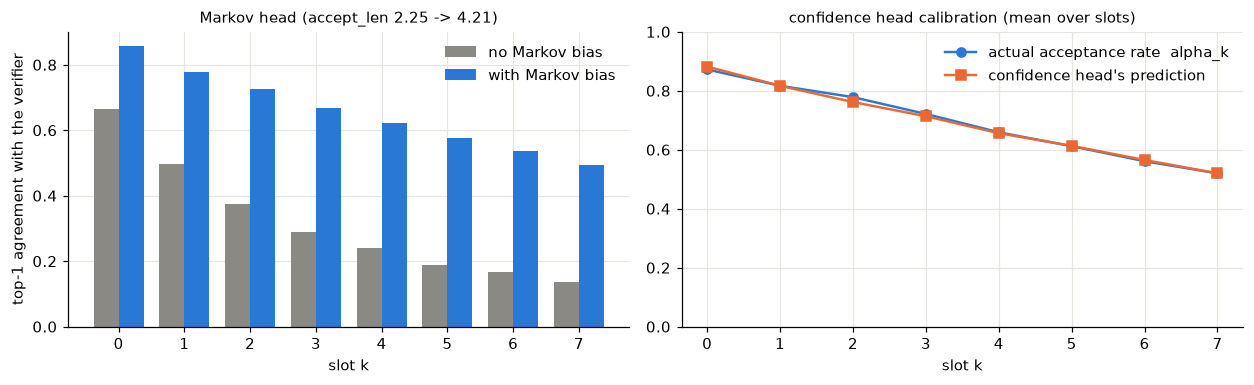

In [24]:
with_m, without_m = evaluate(real, all_rows, use_markov=True), evaluate(real, all_rows, use_markov=False)
acc_with = [with_m[f"position_{k}_acc"] for k in range(BLOCK_SIZE)]; acc_without = [without_m[f"position_{k}_acc"] for k in range(BLOCK_SIZE)]

# confidence calibration: predicted vs actual acceptance rate per slot, from one forward pass
b = make_batches(all_rows, SEQ_LENGTH)[0]
with torch.no_grad(), torch.autocast("cuda", dtype=torch.bfloat16):
    _, mm = real(b["hidden_states"], b["input_ids"], b["loss_mask"], b["last_hs"], b["document_ids"], b["position_ids"], return_tensors=True)
Tt = mm.pop("_tensors")
alpha_k = (1 - tv_loss(Tt["logits"], Tt["targets"])).view(-1, BLOCK_SIZE); conf_k = Tt["conf"].float().sigmoid().view(-1, BLOCK_SIZE); mk = Tt["mask"].view(-1, BLOCK_SIZE)
a_mean = ((alpha_k * mk).sum(0) / mk.sum(0)).cpu().numpy(); c_mean = ((conf_k * mk).sum(0) / mk.sum(0)).cpu().numpy()

fig, axs = plt.subplots(1, 2, figsize=(11.5, 3.6))
x = np.arange(BLOCK_SIZE); w = 0.38
axs[0].bar(x - w/2, acc_without, w, color=GREY, label="no Markov bias"); axs[0].bar(x + w/2, acc_with, w, color=BLUE, label="with Markov bias")
axs[0].set_xlabel("slot k"); axs[0].set_ylabel("top-1 agreement with the verifier"); axs[0].set_title(f"Markov head (accept_len {without_m['accept_len']:.2f} -> {with_m['accept_len']:.2f})", fontsize=10); axs[0].legend(frameon=False)
axs[1].plot(x, a_mean, marker="o", color=BLUE, label="actual acceptance rate  alpha_k"); axs[1].plot(x, c_mean, marker="s", color=ORANGE, label="confidence head's prediction")
axs[1].set_xlabel("slot k"); axs[1].set_title("confidence head calibration (mean over slots)", fontsize=10); axs[1].legend(frameon=False); axs[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

**Now the honest test: real speculative decoding on prompts neither drafter has seen.** We take held-out Open-PerfectBlend prompts, decode with the verifier alone as the reference, then with each drafter, and count
**tokens per verifier step** (how many tokens the verifier "gets" for one forward pass; plain decoding is exactly 1.0). Compare with the teacher-forced `eal` above: they measure the same idea but the
real loop uses the drafter's own Markov chain and the verifier's own context, so they are close but not equal.

In [25]:
unseen = []
for s in spare[:6]:
    first_user = next(i for i, t in enumerate(s["turns"]) if t["role"] == "user")
    unseen.append(chat_prompt_ids(s["turns"][: first_user + 1]))
MAXN = 160
results = {}
for name, mdl in (("ours (20 rows)", draft), ("100k checkpoint", real)):
    tps, lossless = [], []
    for p in unseen:
        out, rnds = speculative_generate(mdl, p, MAXN); ref = greedy_reference(p, len(out))
        tps.append(tokens_per_step(rnds, len(out))); lossless.append(out == ref[:len(out)])
        if name.startswith("100k") and len(tps) == 1: demo_rounds = rnds
    results[name] = (np.mean(tps), tps, all(lossless))
print(f"{'drafter':20s}{'tokens per verifier step':>28s}   per prompt{'':25s}identical to greedy?")
for name, (mean, tps, ok) in results.items():
    print(f"{name:20s}{mean:28.2f}   {[round(t, 2) for t in tps]}   {ok}")
print("\nplain greedy decoding = 1.00 tokens per step by definition.")
show_rounds(demo_rounds, n=6, start=4)

drafter                 tokens per verifier step   per prompt                         identical to greedy?
ours (20 rows)                              1.25   [1.29, 1.33, 1.31, 1.19, 1.14, 1.23]   True
100k checkpoint                             3.58   [4.57, 4.1, 3.64, 3.33, 2.5, 3.33]   True

plain greedy decoding = 1.00 tokens per step by definition.


round 4,'7',' -',' n',')',' and',' ','3',' +',accepted 5/8 (+1 bonus = 6 tokens),confidence survival: 1.00 0.85 0.80 0.57 ...
round 5,'n',' +',' ','3',')',' is',' divided',' by',accepted 8/8 (+1 bonus = 9 tokens),confidence survival: 1.00 0.95 0.95 0.92 ...
round 6,"','",' and',' we',"""'re""",' told',' that',' the',' answer',accepted 0/8 (+1 bonus = 1 tokens),confidence survival: 0.79 0.49 0.33 0.27 ...
round 7,' And',' we',"""'re""",' told',' that',' the',' answer',' is',accepted 5/8 (+1 bonus = 6 tokens),confidence survival: 0.67 0.44 0.30 0.20 ...
round 8,' we',' know',' the',' answer',' is',' ','3',"','",accepted 8/8 (+1 bonus = 9 tokens),confidence survival: 0.77 0.66 0.56 0.46 ...
round 9,' is',' the',' value',' of',' X','?⏎⏎','Hmm',"','",accepted 1/8 (+1 bonus = 2 tokens),confidence survival: 0.97 0.85 0.81 0.76 ...


### Browse a block (interactive)

Pick any anchor in the packed sequence and see, slot by slot, what the **verifier** would say, what the **100k drafter** says (with the Markov bias), whether they agree, the analytical acceptance rate
`alpha`, and the confidence head's guess. Teacher-forced, so every slot sees the real previous token.

In [26]:
anchors_abs = (Tt["block_idx"].view(-1, BLOCK_SIZE)[:, 0]).cpu()
valid_blocks = [i for i in range(len(anchors_abs)) if mk[i].sum() == BLOCK_SIZE]
ids_b = b["input_ids"][0]; d2t_cpu = real.d2t.cpu()

def browse(i=0):
    j = valid_blocks[i]; a = int(anchors_abs[j])
    ctx = tok.decode(ids_b[max(0, a - 25): a + 1].tolist())
    v_arg, d_arg = Tt["targets"].view(-1, BLOCK_SIZE, DRAFT_VOCAB_SIZE)[j].argmax(-1).cpu(), Tt["logits"].view(-1, BLOCK_SIZE, DRAFT_VOCAB_SIZE)[j].argmax(-1).cpu()
    rows_ = []
    for k in range(BLOCK_SIZE):
        true_tok = tok.decode([int(ids_b[a + k + 1])]); vt = tok.decode([int(v_arg[k] + d2t_cpu[v_arg[k]])]); dt = tok.decode([int(d_arg[k] + d2t_cpu[d_arg[k]])])
        ok = int(v_arg[k]) == int(d_arg[k])
        rows_.append(f'<tr style="background:{"#e3f6ec" if ok else "#fdecea"}"><td>{k}</td><td>{true_tok!r}</td><td>{vt!r}</td><td>{dt!r}</td><td>{"✓" if ok else "✗"}</td>'
                     f'<td>{alpha_k[j, k]:.2f}</td><td>{conf_k[j, k]:.2f}</td></tr>')
    display(HTML(f'<div style="font-family:monospace;font-size:12px"><b>anchor at position {a}</b>, context: <i>...{ctx!r}</i> (the last token is the anchor)'
                 f'<table style="border-collapse:collapse;margin-top:6px"><tr><th>slot</th><th>text</th><th>verifier argmax</th><th>drafter argmax</th><th>agree</th><th>alpha</th><th>confidence</th></tr>{"".join(rows_)}</table></div>'))
browse(3)
try:
    import ipywidgets as W
    W.interact(browse, i=W.IntSlider(min=0, max=len(valid_blocks) - 1, step=1, value=3, description="block"))
except Exception as e:
    print("(ipywidgets not available; call browse(i) manually)", e)

slot,text,verifier argmax,drafter argmax,agree,alpha,confidence
0,' think',' think',' think',✓,1.00,0.98
1,' about',' about',' about',✓,0.91,0.95
2,' how',' how',' how',✓,0.97,0.89
3,' to',' to',' to',✓,0.99,0.92
4,' approach',' approach',' approach',✓,0.99,0.79
5,' this',' this',' this',✓,0.94,0.75
6,'.','.','.',✓,0.61,0.47
7,' \n\n',' \n\n',' \n\n',✓,0.62,0.55


interactive(children=(IntSlider(value=3, description='block', max=254), Output()), _dom_classes=('widget-inter…

## 10. What to try next

Each of these is a one-line change near the top of the notebook (re-run from §0). Predict the outcome before you run it.

1. **`ENABLE_THINKING = False`**: shorter, more predictable replies. Does the real-decoding `tokens per verifier step` of the 100k checkpoint change? (It was trained on thinking-on text.)
2. **`MARKOV_HEAD_TYPE = "rnn"`** or `"gated"`: the paper reports the RNN head is only marginally better. With ~20 rows can you even see it? What does the `rnn` loop in `MarkovHead.block_bias` cost in time?
3. **`GAMMA`** (try 2 and 8): changes how strongly the loss favours early slots; look at the per-slot accuracy bars.
4. **`MAX_ANCHORS`** (64 vs 512): more anchors per step = more supervision per step, at higher cost.
5. **`BLOCK_SIZE`** (4 or 16): the real run uses 8. A longer block gives more upside but later slots are harder (compare the paper's Figure 4).
6. **Data**: raise `N_CONVS` to 100 (regeneration takes ~5 minutes) and watch the gap between the train and val curves in §7 shrink.
7. **Stochastic verification**: replace the greedy check in `speculative_generate` by rejection sampling (`accept x with probability min(1, p(x)/q(x))`). That is the setting `accept_len` (the analytical, non-greedy metric) predicts.

**Where to read next in the fork:** `models/dflash/core.py` (the real flex-attention path and the vLLM-facing config), `train/trainer.py` (distributed training, checkpoints, resume), `scripts/launch_vllm.py` (how hidden states are captured and transferred), and `docs/user_guide/algorithms/dspark.md`.